# Whale Instance Segmentation — YOLOv8 on Thermal Grayscale Images

This notebook documents the full pipeline for training and evaluating a YOLOv8 segmentation model on thermal drone images of whales.

**Pipeline overview:**
1. Dataset preparation — RGB → Grayscale conversion
2. Training (with best tuned model)
    - M0: create the new dataset / train, val, test / showing results
    - M1
    - M2

---
## 0. Imports & Global Configuration

In [1]:
# ── Libraries ──────────────────────────────────────────────────────────
import os
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import shutil
import re
import cv2
import matplotlib.patches as mpatches
import random

from collections import Counter
from PIL import Image
from ultralytics import YOLO
from pathlib import Path
from ultralytics.utils.plotting import Annotator, colors

In [2]:
zip_file = "./Flukeprint_detect_behav.v1-2026-05-10-behav.yolov8.zip"
new_name = "05_10_behav_dataset"

# Extract
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(new_name)

print(f"Extracted to {new_name}")

Extracted to 05_10_behav_dataset


In [2]:
# ── Dataset paths ─────────────────────────────────────────────────────────────
DATASET_ROOT  = Path("./05_10_behav_dataset")
DATASET_YAML      = DATASET_ROOT / "data.yaml"

# ── Model weights ─────────────────────────────────────────────────────────────
MODEL_TUNED_PATH    = "./hyper_tuned_best.pt"     # Final tuned model

# ── Model parameters ─────────────────────────────────────────────────────────────
MODEL_PARAMS_PATH = "./best_hyperparameters.yaml"

SPLITS       = ["train", "valid", "test"]

# ── Inference thresholds ─────────────────────────
CONF_THRESHOLD = 0.25  # Confidence threshold
IOU_THRESHOLD  = 0.30  # IoU threshold — intentionally permissive for partial whale detections

---
## 1. Dataset Preparation

### RGB → Grayscale 

The thermal drone images are inherently black-and-white (single-channel), but were saved as 3-channel RGB files by duplicating the same intensity value into R, G and B.

**Why this hurts training:**
- The model wastes capacity learning from redundant colour channels.
- Data augmentation (HSV jitter, colour noise) adds artefacts that don't exist in real thermal imagery, confusing the model.

**Fix:** Convert every image to true 1-channel grayscale before training.

In [5]:
# Convert all RGB images in the dataset to true 1-channel grayscale
# Images are overwritten in-place

total_converted = 0

print("🔄 Starting RGB → Grayscale conversion...")

for split in SPLITS:
    img_dir = Path(DATASET_ROOT) / split / "images"

    if not img_dir.exists():
        print(f"   ⚠️  Skipped '{split}': directory not found at {img_dir}")
        continue

    files = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.jpeg")) + list(img_dir.glob("*.png"))

    if not files:
        print(f"   ⚠️  Skipped '{split}': no images found.")
        continue

    print(f"   Processing '{split}' ({len(files)} images)...")

    for img_path in files:
        try:
            img = Image.open(img_path)
            if img.mode == "RGB":
                img.convert("L").save(img_path)  # L = 8-bit grayscale
                total_converted += 1
        except Exception as e:
            print(f"   ❌ Error on {img_path.name}: {e}")

print(f"\n✅ Done — {total_converted} images converted to true 1-channel grayscale.")

🔄 Starting RGB → Grayscale conversion...
   Processing 'train' (697 images)...
   Processing 'valid' (149 images)...
   Processing 'test' (149 images)...

✅ Done — 995 images converted to true 1-channel grayscale.


In [3]:
# Verify dataset split sizes and confirm images are truly grayscale

print("📂 Dataset split sizes:")
for split in SPLITS:
    img_dir = Path(DATASET_ROOT) / split / "images"
    images = list(img_dir.rglob("*.jpg")) + list(img_dir.rglob("*.png"))
    print(f"   {split:6s}: {len(images)} images")

# Spot-check one image to confirm channel count
sample_img_path = next((Path(DATASET_ROOT) / "train" / "images").rglob("*.jpg"))
img = Image.open(sample_img_path)
channels = len(img.getbands())
print(f"\n🔍 Sample image: {sample_img_path.name}")
print(f"   Size: {img.width} x {img.height} px")
print(f"   Channels: {channels} ({'✅ Grayscale' if channels == 1 else '❌ Still RGB — rerun conversion'})")

📂 Dataset split sizes:
   train : 697 images
   valid : 149 images
   test  : 149 images

🔍 Sample image: video_013_event7_A007_740_t-00240s_jpg.rf.9a7dd7ac2122dbc08adc0b8ca0b4a8bd.jpg
   Size: 448 x 448 px
   Channels: 1 (✅ Grayscale)


---
## M0 - Binary Detection

### Label transformation

- All classes → 0 (flukeprint)
- Writes to a new dataset folder, never overwrites the original

In [9]:
# ── config ────────────────────────────────────────────────────────────────────
OUTPUT_ROOT  = Path("dataset_M0")
# ─────────────────────────────────────────────────────────────────────────────


def transform_label_file(src: Path, dst: Path) -> tuple[int, int]:
    """
    Read a YOLOv8 polygon label file, remap classes, write to dst.
    Returns (total_annotations, remapped_count).
    """
    lines = src.read_text().splitlines()
    out_lines = []
    total = remapped = 0

    for line in lines:
        line = line.strip()
        if not line:
            out_lines.append(line)
            continue

        parts = line.split()
        cls = int(parts[0])
        total += 1

        parts[0] = "0"
        remapped += 1

        out_lines.append(" ".join(parts))

    dst.parent.mkdir(parents=True, exist_ok=True)
    dst.write_text("\n".join(out_lines))
    return total, remapped


def main():

    grand_total = grand_remapped = 0

    for split in SPLITS:
        img_src = DATASET_ROOT / split / "images"
        lbl_src = DATASET_ROOT / split / "labels"
        img_dst = OUTPUT_ROOT  / split / "images"
        lbl_dst = OUTPUT_ROOT  / split / "labels"

        # ── images: copy as-is ───────────────────────────────────────────────
        if img_src.exists():
            if img_dst.exists():
                shutil.rmtree(img_dst)
            shutil.copytree(img_src, img_dst)
            n_imgs = len(list(img_dst.iterdir()))
            print(f"[{split}] copied {n_imgs} images")
        else:
            print(f"[{split}] no images folder found, skipping")

        # ── labels: remap classes ────────────────────────────────────────────
        if not lbl_src.exists():
            print(f"[{split}] no labels folder found, skipping")
            continue

        lbl_dst.mkdir(parents=True, exist_ok=True)
        split_total = split_remapped = 0

        for lbl_file in sorted(lbl_src.glob("*.txt")):
            t, r = transform_label_file(lbl_file, lbl_dst / lbl_file.name)
            split_total    += t
            split_remapped += r

        grand_total    += split_total
        grand_remapped += split_remapped
        print(f"[{split}] {split_total} annotations — "
              f"{split_remapped} remapped to class 0")

    # ── copy + patch yaml if present ─────────────────────────────────────────
    for yaml_file in DATASET_ROOT.glob("*.yaml"):
        content = yaml_file.read_text()
        content = re.sub(r"nc\s*:\s*\d+", "nc: 1", content)
        content = re.sub(
            r"names\s*:.*?(?=\n\S|\Z)",
            "names:\n  0: flukeprint",
            content,
            flags=re.DOTALL,
        )
        dst_yaml = OUTPUT_ROOT / yaml_file.name
        dst_yaml.parent.mkdir(parents=True, exist_ok=True)
        dst_yaml.write_text(content)
        print(f"[yaml] patched and copied → {dst_yaml}")

    print(f"\n✓ Done. Output: {OUTPUT_ROOT.resolve()}")
    print(f"  Total annotations : {grand_total}")
    print(f"  Remapped → class 0: {grand_remapped}")

In [ ]:
if __name__ == "__main__":
    main()

### M0 Training

In [4]:
# ── Training with best hyperparameters ──────────────────────────────────
# Load the best hyperparameters found by the tuner and train.

# ── config ────────────────────────────────────────────────────────────────────
M0_DATASET  = Path("dataset_M0")
M0_YAML     = M0_DATASET / "data.yaml"
# ─────────────────────────────────────────────────────────────────────────────

with open(MODEL_PARAMS_PATH) as f:
    best_params = yaml.safe_load(f)

model_tuned = YOLO(MODEL_TUNED_PATH)

In [8]:
model_tuned.train(
    data=M0_YAML,
    epochs=150,        
    imgsz=448,
    patience=20,
    name="train_M0",
    **best_params      
)

New https://pypi.org/project/ultralytics/8.4.48 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24215MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.00784, box=5.14291, cache=False, cfg=None, classes=None, close_mosaic=6, cls=0.55957, compile=False, conf=None, copy_paste=0.00314, copy_paste_mode=flip, cos_lr=False, cutmix=0.00571, data=dataset_M0/data.yaml, degrees=0.00017, deterministic=True, device=None, dfl=1.36906, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.48872, flipud=0.0018, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01493, hsv_s=0.64776, hsv_v=0.27383, imgsz=448, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.00218, lrf=0.02127, mask_ratio=4, max_det=300, mixup=0.00285, mode=train, model=./hyper_tuned_

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f2ab8eb43a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 

### M0 Evaluation

In [12]:
# ── Validation — M0 ───────────────────────────────────────────────

M0_BEST = Path("runs/segment/train_M0/weights/best.pt")  

final_model = YOLO(M0_BEST)

metrics = final_model.val(
    data=M0_YAML,
    split="val",
    conf=CONF_THRESHOLD,
    iou=0.1,
    verbose=True,
    plots=True
)

print("\n" + "=" * 60)
print("M0 VALIDATION RESULTS — Tuned Model (best.pt)")
print("=" * 60)
print(f"mAP50        (Box):  {metrics.box.map50:.4f}")
print(f"mAP50-95     (Box):  {metrics.box.map:.4f}")
print(f"mAP50        (Mask): {metrics.seg.map50:.4f}")
print(f"mAP50-95     (Mask): {metrics.seg.map:.4f}")
print(f"Recall       (Mask): {metrics.seg.r.mean():.4f}")
print(f"Precision    (Mask): {metrics.seg.p.mean():.4f}")
print("=" * 60)


Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24215MiB)
YOLOv8s-seg summary (fused): 86 layers, 11,779,987 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 933.0±251.9 MB/s, size: 12.6 KB)
val: Scanning /home/floreM/FlukePrint_YOLO/behav_model/dataset_M0/valid/labels.cache... 149 images, 20 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 149/149 24.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 5.3it/s 1.9s.2s
                   all        149        514      0.858      0.743      0.838      0.693      0.854      0.719      0.826      0.612
Speed: 1.1ms preprocess, 3.0ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /home/floreM/FlukePrint_YOLO/behav_model/runs/segment/val

M0 VALIDATION RESULTS — Tuned Model (best.pt)
mAP50        (Box):  0.8383
mAP50-95     (Box):  0.6

In [7]:
# ── Final Test Evaluation — M0 ───────────────────────────────────────────────

metrics_test = final_model.val(
    data=M0_YAML,
    split="test",
    conf=CONF_THRESHOLD,
    iou=0.1,
    verbose=True,
    plots=True
)

p  = metrics_test.seg.p.mean()
r  = metrics_test.seg.r.mean()
f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0

print("\n" + "=" * 60)
print("M0 TEST RESULTS — Final Held-Out Evaluation")
print("=" * 60)
print(f"mAP50        (Box):  {metrics_test.box.map50:.4f}")
print(f"mAP50-95     (Box):  {metrics_test.box.map:.4f}")
print(f"mAP50        (Mask): {metrics_test.seg.map50:.4f}")
print(f"mAP50-95     (Mask): {metrics_test.seg.map:.4f}")
print(f"Recall       (Mask): {r:.4f}")
print(f"Precision    (Mask): {p:.4f}")
print(f"F1           (Mask): {f1:.4f}")
print("=" * 60)
print("✓ M0 baseline locked. Safe to proceed to M1.")

Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24215MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 607.7±140.0 MB/s, size: 12.5 KB)
val: Scanning /home/floreM/FlukePrint_YOLO/behav_model/dataset_M0/test/labels.cache... 149 images, 15 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 149/149 48.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 5.4it/s 1.8s.2s
                   all        149        513      0.882      0.743      0.843      0.686      0.855      0.741       0.83      0.603
Speed: 1.4ms preprocess, 1.4ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /home/floreM/FlukePrint_YOLO/behav_model/runs/segment/val2

M0 TEST RESULTS — Final Held-Out Evaluation
mAP50        (Box):  0.8426
mAP50-95     (Box):  0.6859
mAP50        (Mask): 0.8295
mAP50-95     (Mask): 0.6027
Recall       (Mask): 0.7407
Pr

### M0 Visualisation

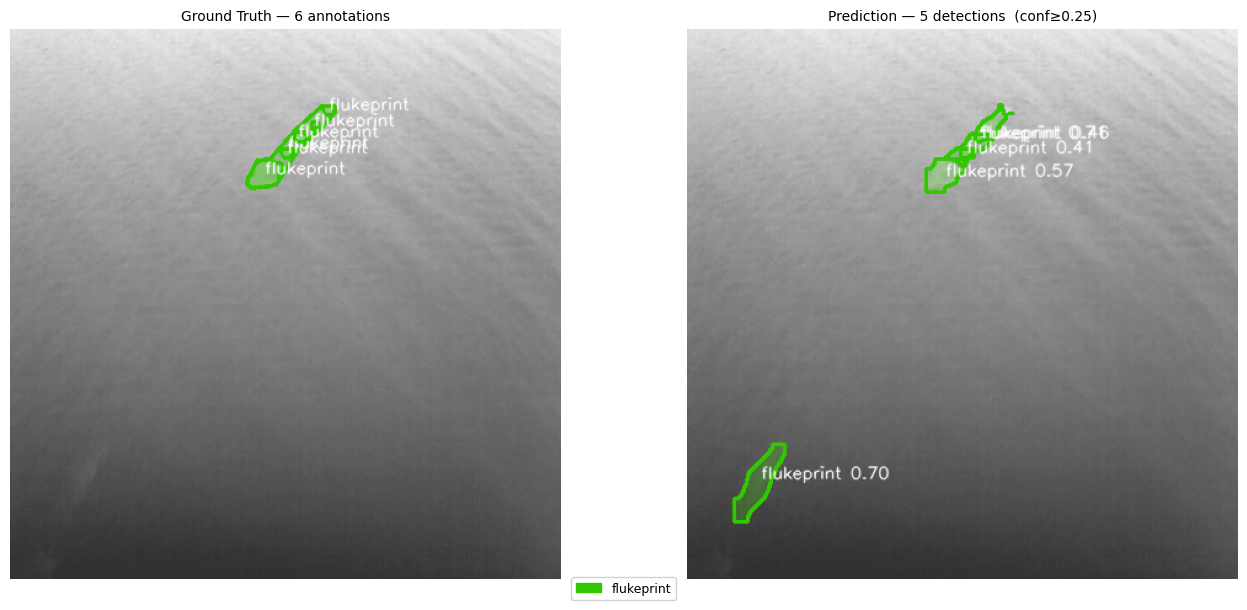

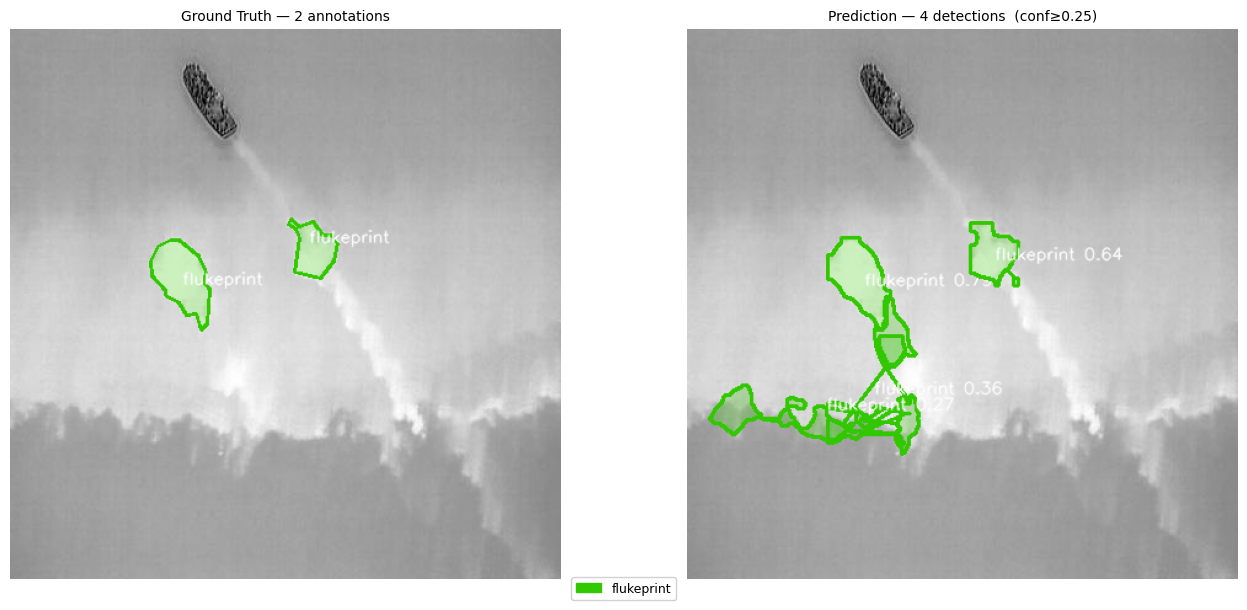

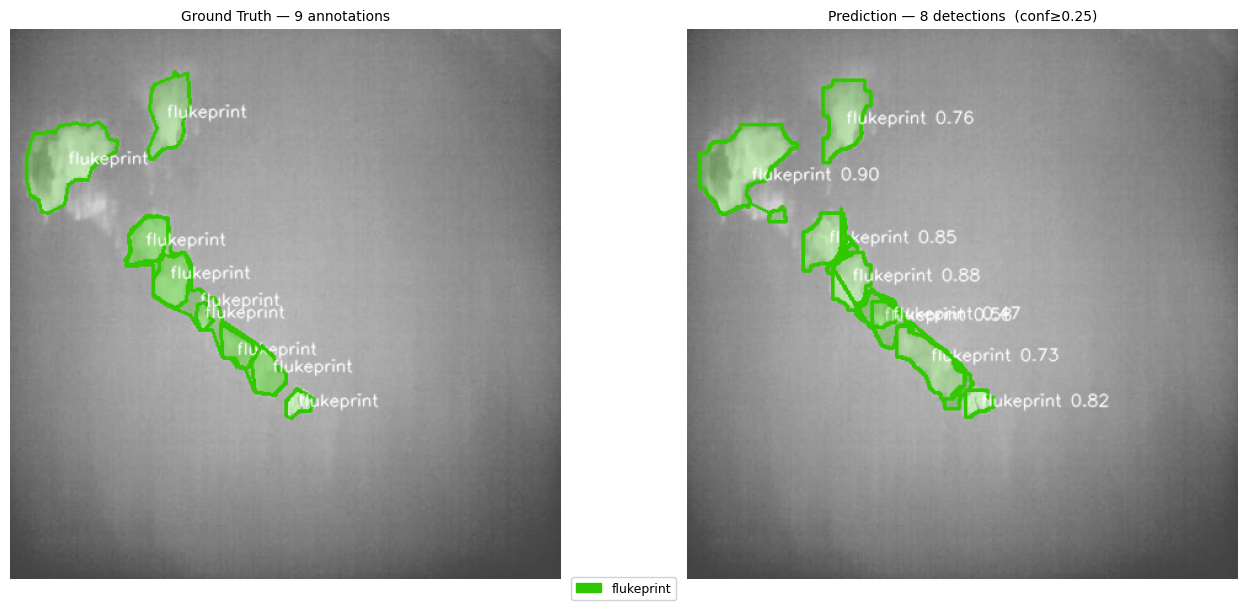

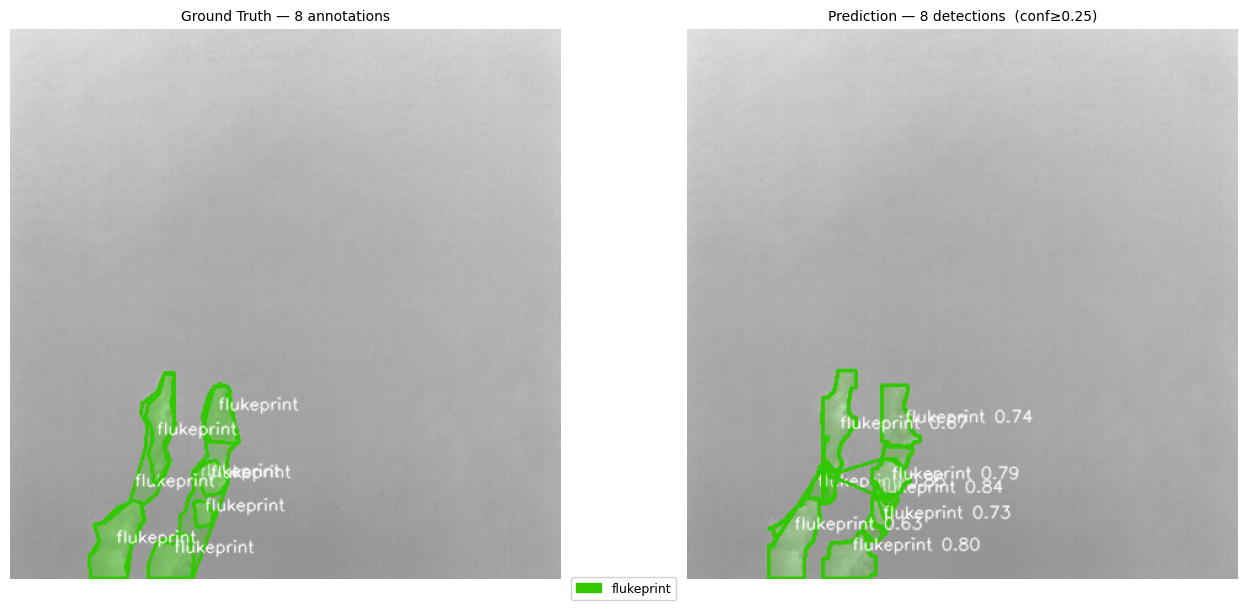

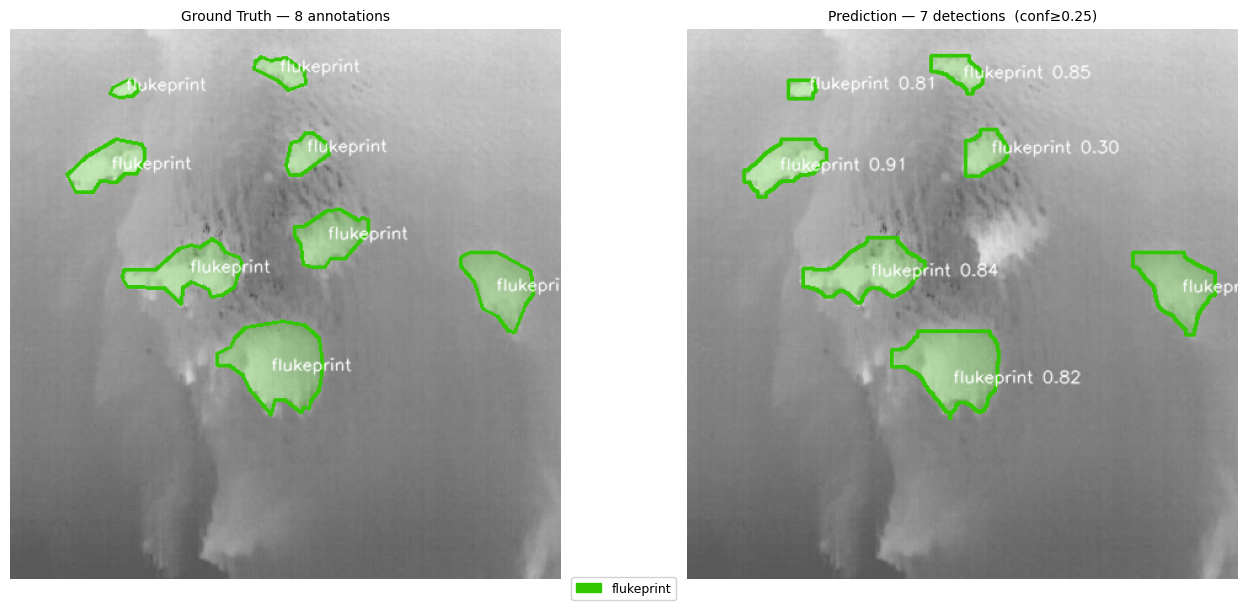

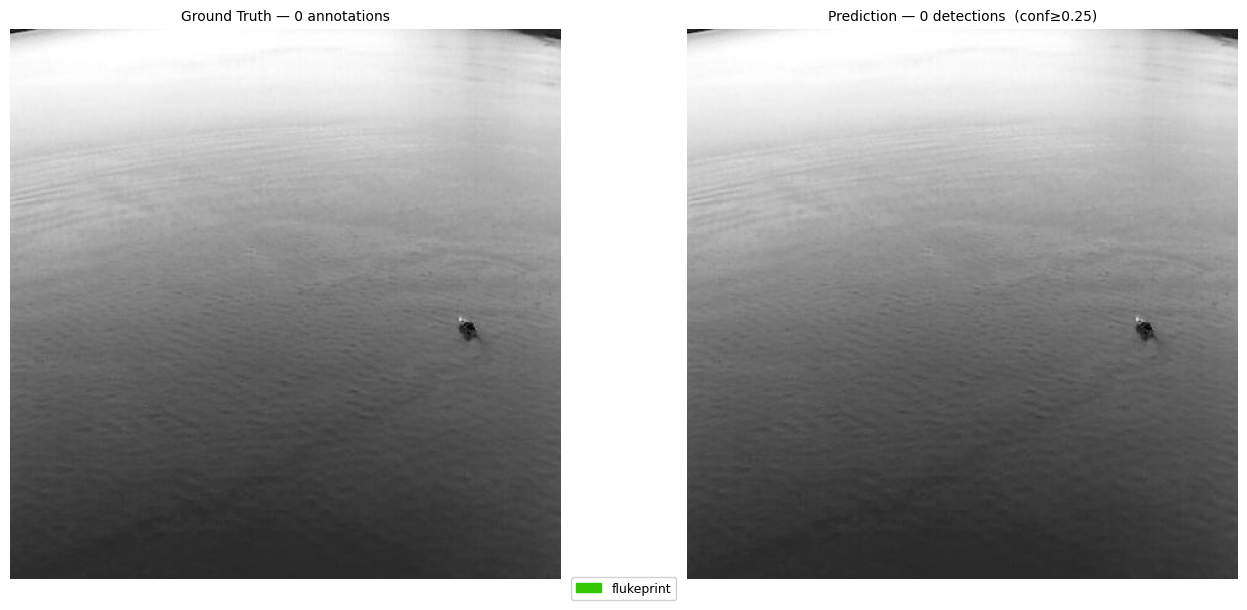

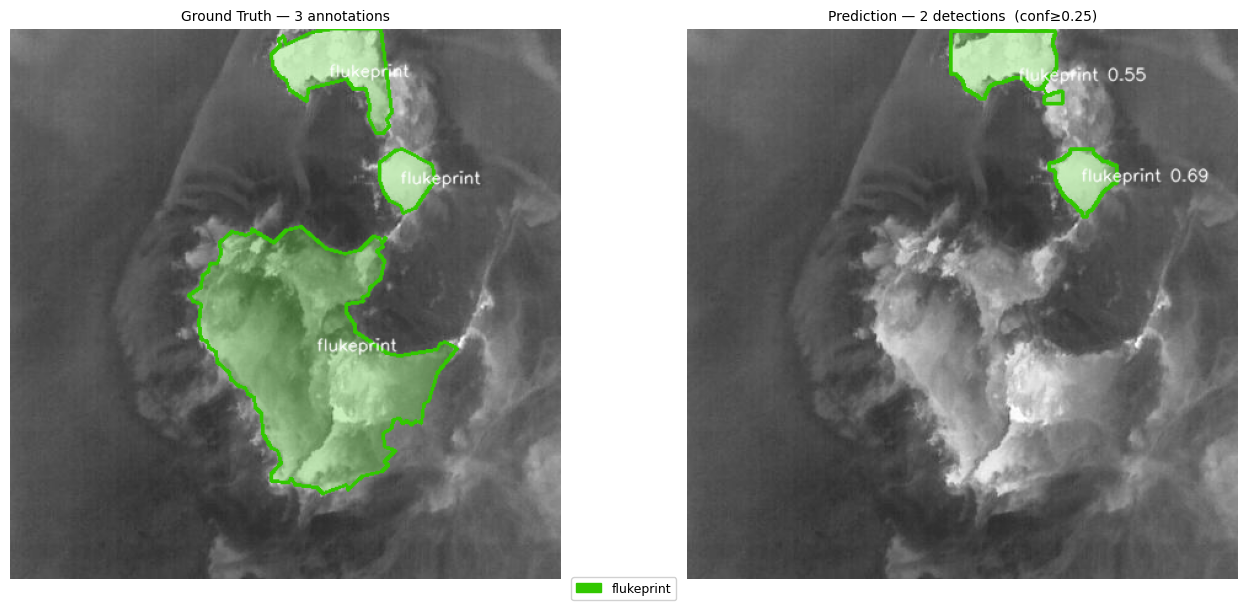

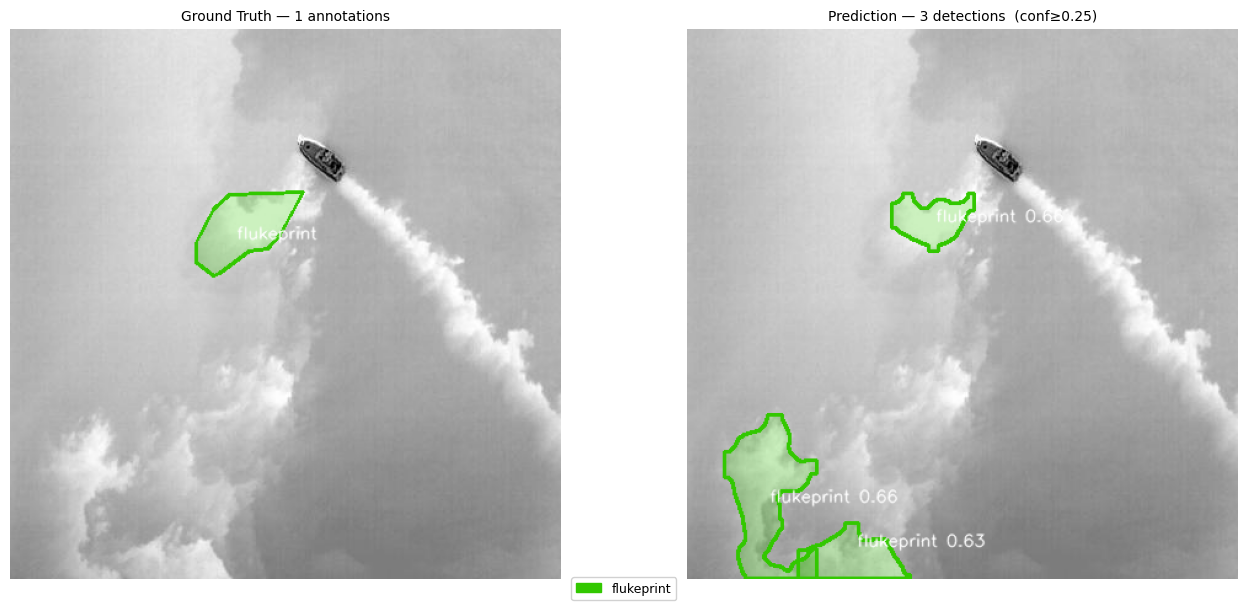

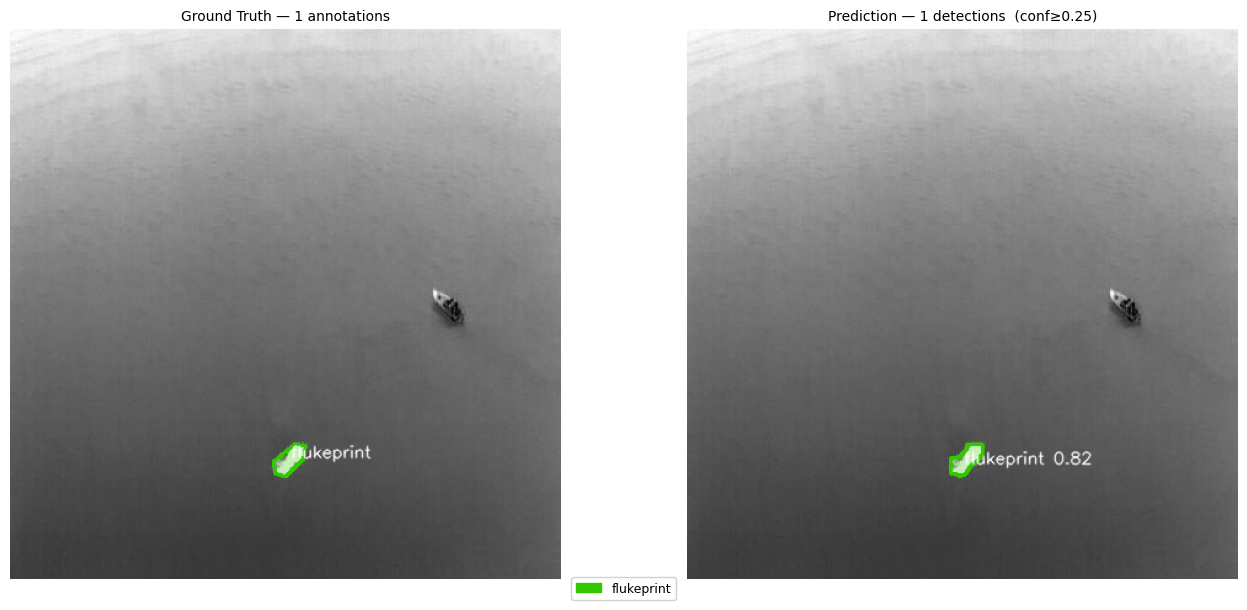

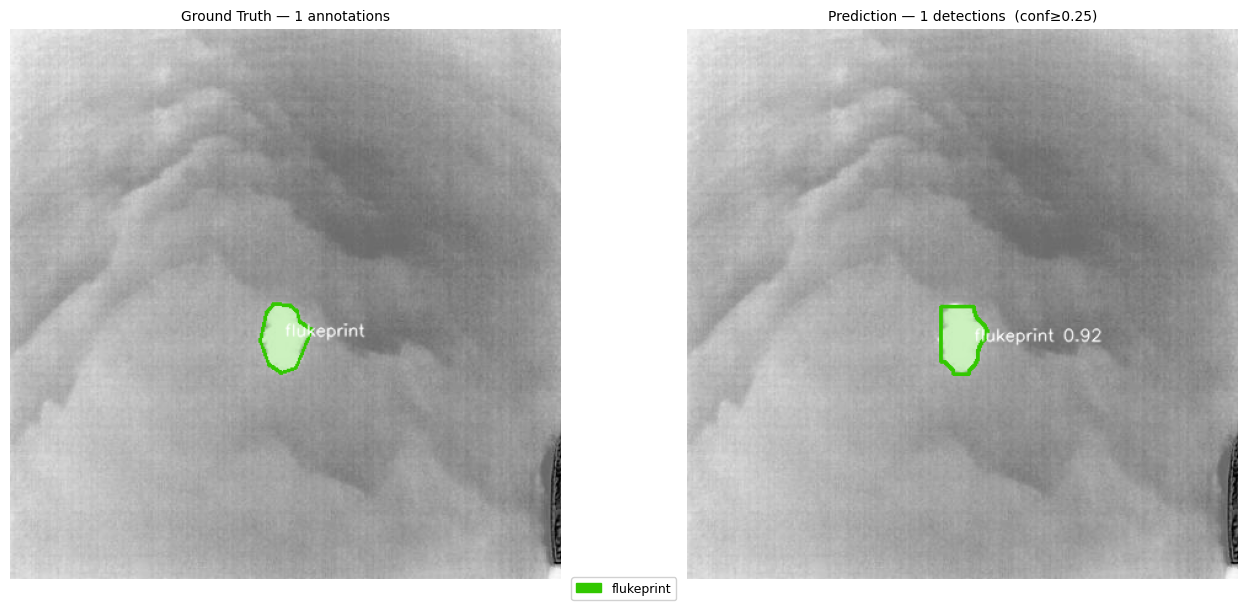

In [6]:
# ── config ────────────────────────────────────────────────────────────────────
PHASE = "M0"   # ← change to "M0", "M1", or "M2"

CONFIGS = {
    "M0": {
        "model_path": Path("runs/segment/train_M0/weights/best.pt"),
        "img_dir":    Path("dataset_M0/test/images"),
        "lbl_dir":    Path("dataset_M0/test/labels"),
        "class_names": {0: "flukeprint"},
        "colors_bgr":  {0: (0, 200, 50)},
    },
    "M1": {
        "model_path": Path("runs/segment/train_M1/weights/best.pt"),
        "img_dir":    Path("dataset_M1/test/images"),
        "lbl_dir":    Path("dataset_M1/test/labels"),
        "class_names": {0: "feeding", 1: "surfacing", 2: "unknown"},
        "colors_bgr":  {0: (0, 200, 50), 1: (0, 80, 255), 2: (180, 0, 255)},
    },
    "M2": {
        "model_path": Path("runs/segment/train_M2/weights/best.pt"),
        "img_dir":    Path("dataset_M2/test/images"),
        "lbl_dir":    Path("dataset_M2/test/labels"),
        "class_names": {
            0: "feeding_fresh", 1: "feeding_old",
            2: "surfacing_fresh", 3: "surfacing_old",
            4: "unknown"
        },
        "colors_bgr": {
            0: (0, 200, 50),      # feeding_fresh   → green
            1: (0, 120, 30),      # feeding_old     → dark green
            2: (0, 80, 255),      # surfacing_fresh → orange
            3: (0, 40, 180),      # surfacing_old   → dark orange
            4: (180, 0, 255),     # unknown         → purple
        },
    },
}

N_IMAGES       = 10
# ─────────────────────────────────────────────────────────────────────────────

cfg         = CONFIGS[PHASE]
model       = YOLO(cfg["model_path"])
class_names = cfg["class_names"]
colors_bgr  = cfg["colors_bgr"]
colors_rgb  = {k: tuple(c/255 for c in reversed(v)) for k, v in colors_bgr.items()}

img_paths = sorted(cfg["img_dir"].glob("*.jpg")) + sorted(cfg["img_dir"].glob("*.png"))
sample    = random.sample(img_paths, min(N_IMAGES, len(img_paths)))


def draw_gt(img_bgr: np.ndarray, lbl_path: Path) -> np.ndarray:
    out = img_bgr.copy()
    h, w = out.shape[:2]
    if not lbl_path.exists():
        return out
    for line in lbl_path.read_text().splitlines():
        parts = line.strip().split()
        if len(parts) < 7:
            continue
        cls_id = int(parts[0])
        coords = list(map(float, parts[1:]))
        pts    = np.array(
            [(coords[i] * w, coords[i+1] * h) for i in range(0, len(coords), 2)],
            dtype=np.int32,
        )
        color = colors_bgr.get(cls_id, (200, 200, 200))
        label = class_names.get(cls_id, str(cls_id))

        overlay = out.copy()
        cv2.fillPoly(overlay, [pts], color=color)
        cv2.addWeighted(overlay, 0.25, out, 0.75, 0, out)
        cv2.polylines(out, [pts], isClosed=True, color=color, thickness=2)

        cx = int(pts[:, 0].mean())
        cy = int(pts[:, 1].mean())
        cv2.putText(out, label, (cx, cy), cv2.FONT_HERSHEY_SIMPLEX,
                    0.45, (255, 255, 255), 1, cv2.LINE_AA)
    return out


def draw_pred(img_bgr: np.ndarray, result) -> np.ndarray:
    out = img_bgr.copy()
    if result.masks is None:
        return out
    for mask_xy, box in zip(result.masks.xy, result.boxes):
        cls_id = int(box.cls)
        conf   = float(box.conf)
        color  = colors_bgr.get(cls_id, (200, 200, 200))
        label  = f"{class_names.get(cls_id, cls_id)} {conf:.2f}"
        pts    = mask_xy.astype(np.int32)

        overlay = out.copy()
        cv2.fillPoly(overlay, [pts], color=color)
        cv2.addWeighted(overlay, 0.25, out, 0.75, 0, out)
        cv2.polylines(out, [pts], isClosed=True, color=color, thickness=2)

        cx = int(pts[:, 0].mean())
        cy = int(pts[:, 1].mean())
        cv2.putText(out, label, (cx, cy), cv2.FONT_HERSHEY_SIMPLEX,
                    0.45, (255, 255, 255), 1, cv2.LINE_AA)
    return out


# ── plot ──────────────────────────────────────────────────────────────────────
for img_path in sample:
    lbl_path = cfg["lbl_dir"] / (img_path.stem + ".txt")
    img_bgr  = cv2.imread(str(img_path))
    result   = model.predict(img_path, conf=CONF_THRESHOLD, iou=IOU_THRESHOLD, verbose=False)[0]

    img_gt   = draw_gt(img_bgr, lbl_path)
    img_pred = draw_pred(img_bgr, result)

    gt_lines = [l for l in lbl_path.read_text().splitlines() if l.strip()] if lbl_path.exists() else []
    n_gt     = len(gt_lines)
    n_pred   = len(result.boxes) if result.boxes is not None else 0

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(cv2.cvtColor(img_gt,   cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Ground Truth — {n_gt} annotations", fontsize=10)
    axes[0].axis("off")

    axes[1].imshow(cv2.cvtColor(img_pred, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"Prediction — {n_pred} detections  (conf≥{CONF_THRESHOLD})", fontsize=10)
    axes[1].axis("off")

    patches = [
        mpatches.Patch(color=colors_rgb[i], label=name)
        for i, name in class_names.items()
    ]
    fig.legend(handles=patches, loc="lower center", ncol=len(class_names),
               fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.02))
    
    plt.tight_layout()
    plt.show()

---
## M1 - Behavioral Distinction - with unknown class

### Label transformation

Original 9 classes → 4 behavioral classes (background is implicit, never labeled)

    0: feeding_fresh          → 0: Feeding
    1: feeding_old            → 0: Feeding
    2: surfacing_fresh        → 1: Surfacing
    3: surfacing_fresh_travel → 1: Surfacing
    4: surfacing_old          → 1: Surfacing
    5: surfacing_old_travel   → 1: Surfacing
    6: traveling_fresh        → DISCARD
    7: traveling_old          → DISCARD
    8: unknown                → 2: Unknown

Writes to a new dataset folder, never overwrites the original

In [17]:
# ── config ────────────────────────────────────────────────────────────────────
OUTPUT_ROOT  = Path("dataset_M1")

CLASS_MAP = {
    0: 0,   # feeding_fresh          → Feeding
    1: 0,   # feeding_old            → Feeding
    2: 1,   # surfacing_fresh        → Surfacing
    3: 1,   # surfacing_fresh_travel → Surfacing
    4: 1,   # surfacing_old          → Surfacing
    5: 1,   # surfacing_old_travel   → Surfacing
    6: None,   # traveling_fresh        → DISCARD
    7: None,   # traveling_old          → DISCARD
    8: 2,   # unknown                → Unknown
}

CLASS_NAMES = {
    0: "feeding",
    1: "surfacing",
    2: "unknown",
}
# ─────────────────────────────────────────────────────────────────────────────


def transform_label_file(src: Path, dst: Path) -> tuple[Counter, int]:
    lines = src.read_text().splitlines()
    out_lines = []
    counts    = Counter()
    discarded = 0

    for line in lines:
        line = line.strip()
        if not line:
            continue

        parts = line.split()
        original_cls = int(parts[0])

        if original_cls not in CLASS_MAP:
            raise ValueError(
                f"Unexpected class {original_cls} in {src}. "
                f"Expected one of {list(CLASS_MAP.keys())}"
            )

        new_cls = CLASS_MAP[original_cls]

        if new_cls is None:       # ← traveling → skip, don't write
            discarded += 1
            continue

        parts[0] = str(new_cls)
        counts[new_cls] += 1
        out_lines.append(" ".join(parts))

    dst.parent.mkdir(parents=True, exist_ok=True)
    dst.write_text("\n".join(out_lines))  # may write empty file — that's fine
    return counts, discarded


def main():
    if not DATASET_ROOT.exists():
        raise FileNotFoundError(f"DATASET_ROOT not found: {DATASET_ROOT.resolve()}")

    if OUTPUT_ROOT.exists():
        print(f"[warn] Output folder already exists: {OUTPUT_ROOT.resolve()}")
        print("       Delete it manually if you want a clean run.")

    grand_counts = Counter()

    for split in SPLITS:
        img_src = DATASET_ROOT / split / "images"
        lbl_src = DATASET_ROOT / split / "labels"
        img_dst = OUTPUT_ROOT  / split / "images"
        lbl_dst = OUTPUT_ROOT  / split / "labels"

        # ── images: copy as-is ───────────────────────────────────────────────
        if img_src.exists():
            if img_dst.exists():
                shutil.rmtree(img_dst)
            shutil.copytree(img_src, img_dst)
            n_imgs = len(list(img_dst.iterdir()))
            print(f"[{split}] copied {n_imgs} images")
        else:
            print(f"[{split}] no images folder found, skipping")

        # ── labels: remap classes ────────────────────────────────────────────
        if not lbl_src.exists():
            print(f"[{split}] no labels folder found, skipping")
            continue

        lbl_dst.mkdir(parents=True, exist_ok=True)
        split_counts    = Counter()
        split_discarded = 0

        for lbl_file in sorted(lbl_src.glob("*.txt")):
            counts, discarded = transform_label_file(lbl_file, lbl_dst / lbl_file.name)
            split_counts    += counts
            split_discarded += discarded

        grand_counts += split_counts

        print(f"[{split}] annotation breakdown:")
        for cls_id, name in CLASS_NAMES.items():
            print(f"         class {cls_id} ({name:12s}): {split_counts[cls_id]}")
        print(f"         discarded (traveling)  : {split_discarded}")

    # ── write yaml ───────────────────────────────────────────────────────────
    for yaml_file in DATASET_ROOT.glob("*.yaml"):
        content = yaml_file.read_text()
        content = re.sub(r"nc\s*:\s*\d+", "nc: 3", content)
        content = re.sub(
            r"names\s*:.*?(?=\n\S|\Z)",
            (
                "names:\n"
                "  0: feeding\n"
                "  1: surfacing\n"
                "  2: unknown\n"
            ),
            content,
            flags=re.DOTALL,
        )
        dst_yaml = OUTPUT_ROOT / yaml_file.name
        dst_yaml.parent.mkdir(parents=True, exist_ok=True)
        dst_yaml.write_text(content)
        print(f"\n[yaml] patched and copied → {dst_yaml}")

    print(f"\n✓ Done. Output: {OUTPUT_ROOT.resolve()}")
    print(f"\nGlobal annotation breakdown:")
    total = 0
    for cls_id, name in CLASS_NAMES.items():
        n = grand_counts[cls_id]
        total += n
        print(f"  class {cls_id} ({name:12s}): {n:>6} annotations")
    print(f"  {'TOTAL':>18}: {total:>6} annotations")

In [18]:
if __name__ == "__main__":
    main()

[train] copied 697 images
[train] annotation breakdown:
         class 0 (feeding     ): 600
         class 1 (surfacing   ): 1439
         class 2 (unknown     ): 144
         discarded (traveling)  : 230
[valid] copied 149 images
[valid] annotation breakdown:
         class 0 (feeding     ): 150
         class 1 (surfacing   ): 278
         class 2 (unknown     ): 42
         discarded (traveling)  : 44
[test] copied 149 images
[test] annotation breakdown:
         class 0 (feeding     ): 151
         class 1 (surfacing   ): 295
         class 2 (unknown     ): 20
         discarded (traveling)  : 47

[yaml] patched and copied → dataset_M1/data.yaml

✓ Done. Output: /home/floreM/FlukePrint_YOLO/behav_model/dataset_M1

Global annotation breakdown:
  class 0 (feeding     ):    901 annotations
  class 1 (surfacing   ):   2012 annotations
  class 2 (unknown     ):    206 annotations
               TOTAL:   3119 annotations


### M1 with unknown - Training

In [ ]:
# ── Training with best hyperparameters ──────────────────────────────────
# Load the best hyperparameters found by the tuner and train.

# ── config ────────────────────────────────────────────────────────────────────
M1_DATASET      = Path("dataset_M1")
M1_YAML         = M1_DATASET / "data.yaml"
M0_BEST         = Path("runs/segment/train_M0/weights/best.pt")  
# ─────────────────────────────────────────────────────────────────────────────

model_m1 = YOLO(M0_BEST)  

with open(MODEL_PARAMS_PATH) as f:
    best_params = yaml.safe_load(f)


In [20]:
model_m1.train(
    data=M1_YAML,
    epochs=150,  
    imgsz=448,
    patience=20,  
    name="train_M1_with",
    **best_params       
)

New https://pypi.org/project/ultralytics/8.4.51 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24215MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.00784, box=5.14291, cache=False, cfg=None, classes=None, close_mosaic=6, cls=0.55957, compile=False, conf=None, copy_paste=0.00314, copy_paste_mode=flip, cos_lr=False, cutmix=0.00571, data=dataset_M1/data.yaml, degrees=0.00017, deterministic=True, device=None, dfl=1.36906, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.48872, flipud=0.0018, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01493, hsv_s=0.64776, hsv_v=0.27383, imgsz=448, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.00218, lrf=0.02127, mask_ratio=4, max_det=300, mixup=0.00285, mode=train, model=runs/segment/t

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ff64f1bad40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.04

### M1 with unknown - Evaluation

In [21]:
# ── Validation — M1 ───────────────────────────────────────────────

M1_BEST = Path("runs/segment/train_M1_with/weights/best.pt")  

final_model = YOLO(M1_BEST)

metrics = final_model.val(
    data=M1_YAML,
    split="val",
    conf=CONF_THRESHOLD,
    iou=IOU_THRESHOLD,
    verbose=True,
    plots=True
)

p  = metrics.seg.p.mean()
r  = metrics.seg.r.mean()
f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0

print("\n" + "=" * 60)
print("M1 with unknown VALIDATION RESULTS")
print("=" * 60)
print(f"mAP50        (Box):  {metrics.box.map50:.4f}")
print(f"mAP50-95     (Box):  {metrics.box.map:.4f}")
print(f"mAP50        (Mask): {metrics.seg.map50:.4f}")
print(f"mAP50-95     (Mask): {metrics.seg.map:.4f}")
print(f"Recall       (Mask): {r:.4f}")
print(f"Precision    (Mask): {p:.4f}")
print(f"F1           (Mask): {f1:.4f}")
print("=" * 60)


Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24215MiB)
YOLOv8s-seg summary (fused): 86 layers, 11,780,761 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 639.0±162.8 MB/s, size: 10.0 KB)
val: Scanning /home/floreM/FlukePrint_YOLO/behav_model/dataset_M1/valid/labels.cache... 149 images, 20 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 149/149 32.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 4.7it/s 2.1s.3s
                   all        149        470      0.615      0.741      0.692       0.55      0.633       0.71      0.694      0.488
               feeding         69        150      0.679       0.86      0.837      0.712      0.723      0.853      0.841      0.659
             surfacing        104        278      0.705      0.719      0.748       0.59      0.704      0.683      0.746  

### M1 Visualisation

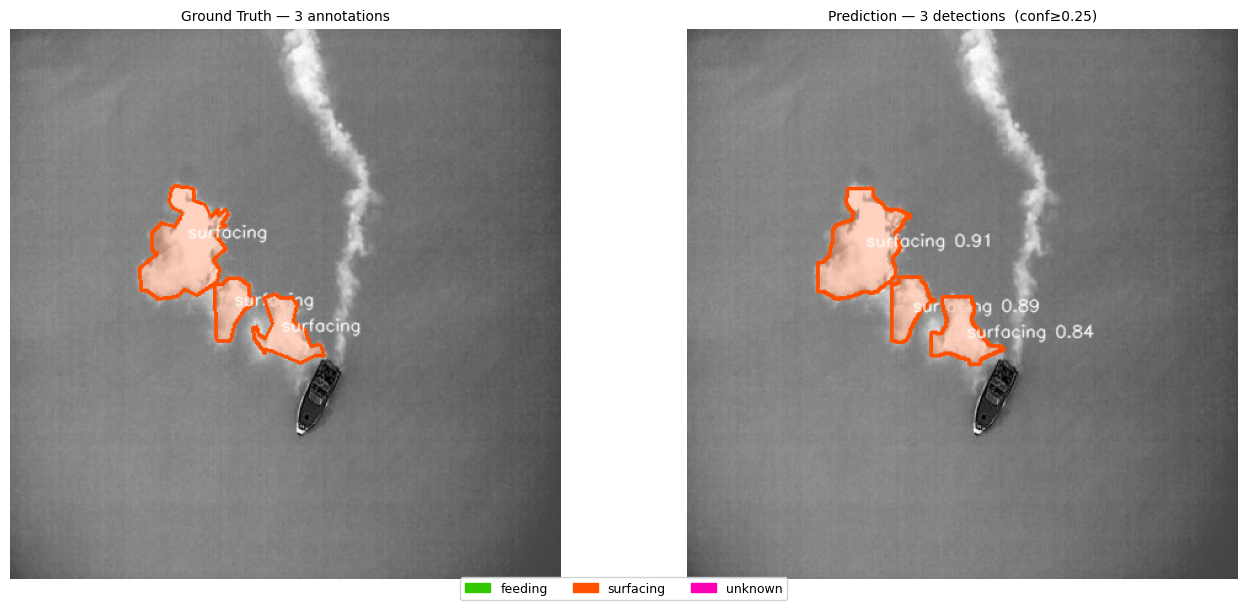

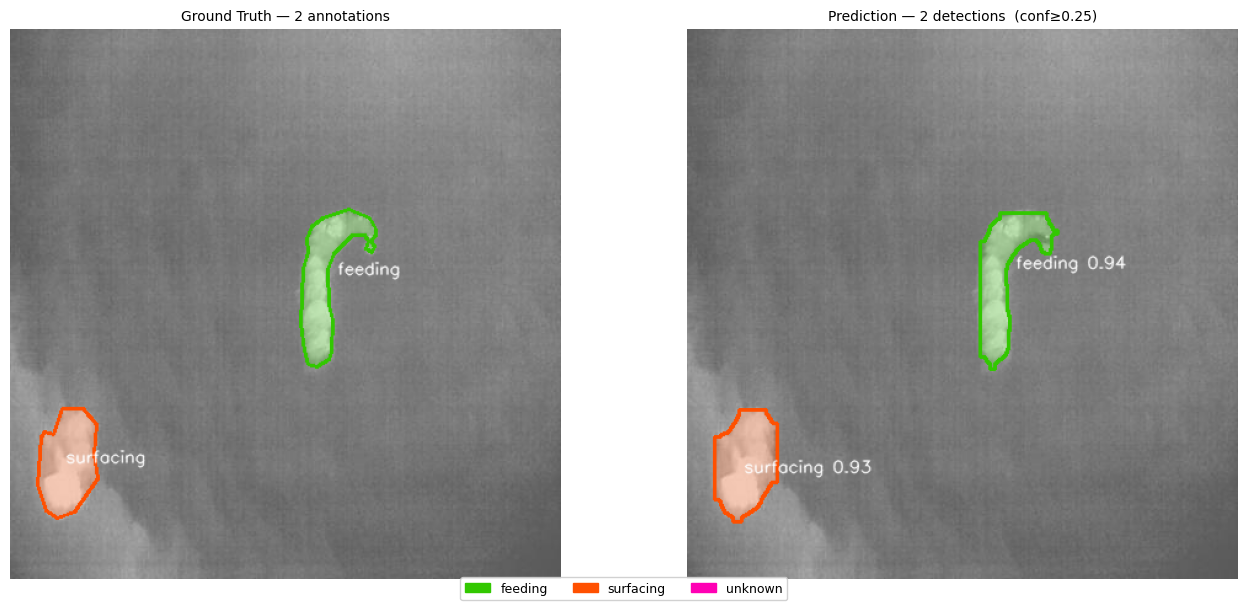

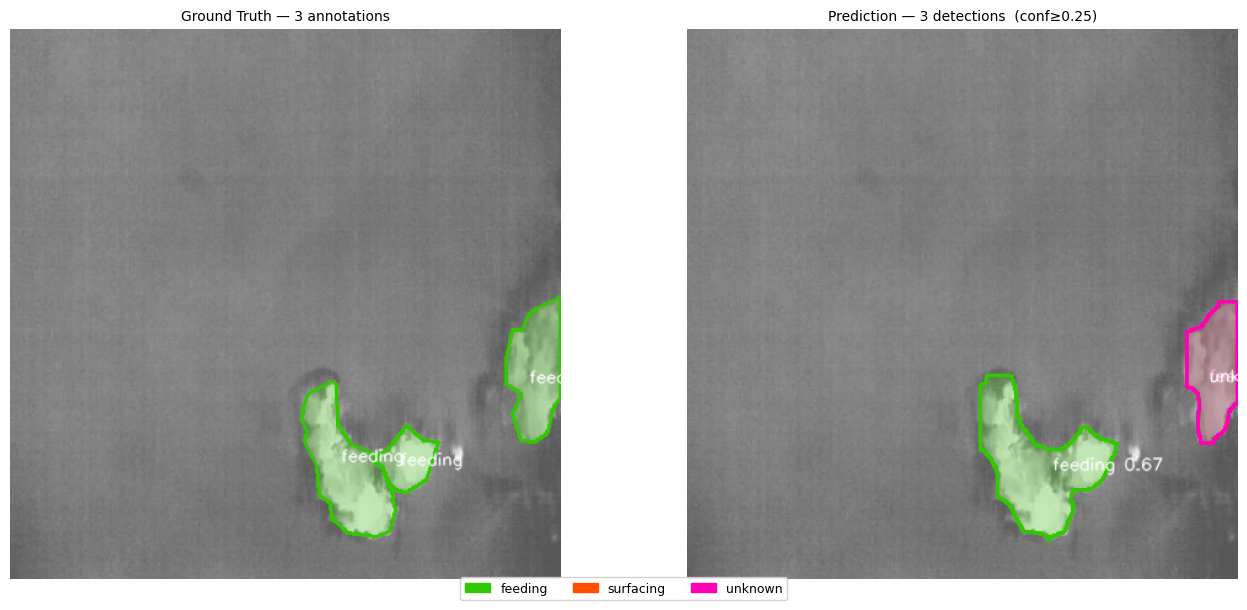

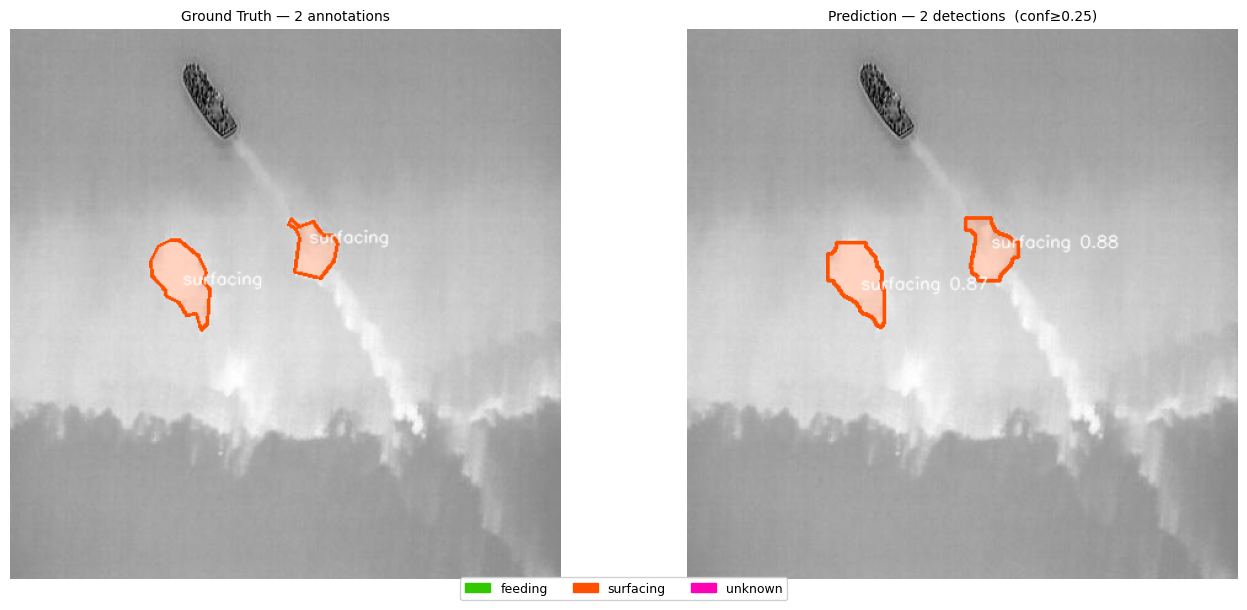

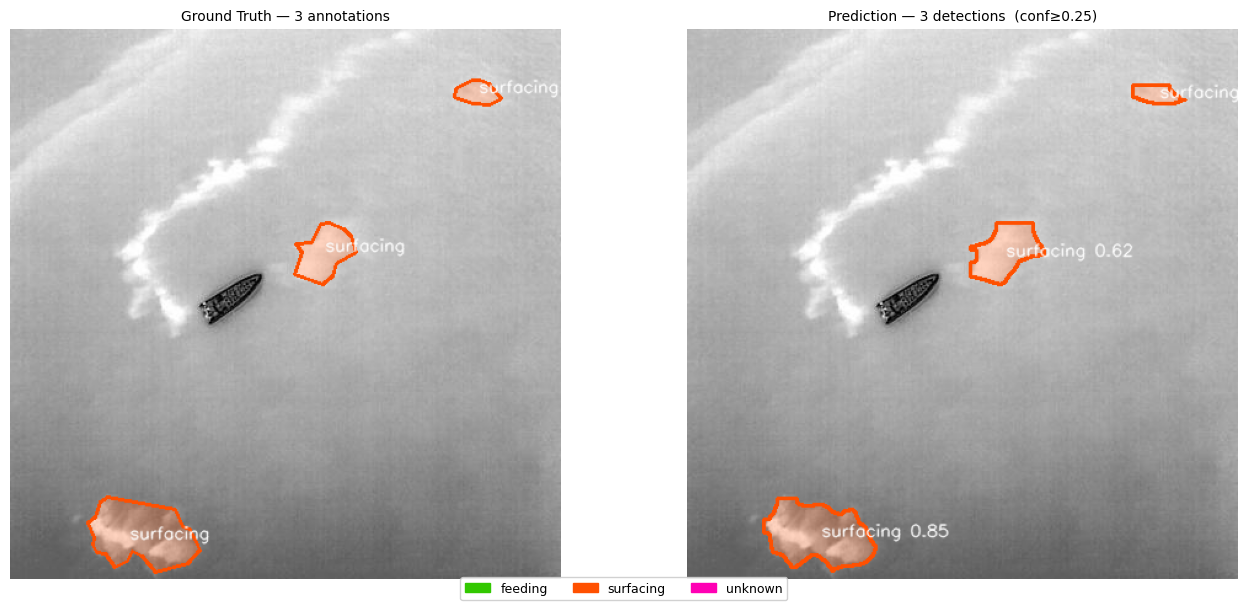

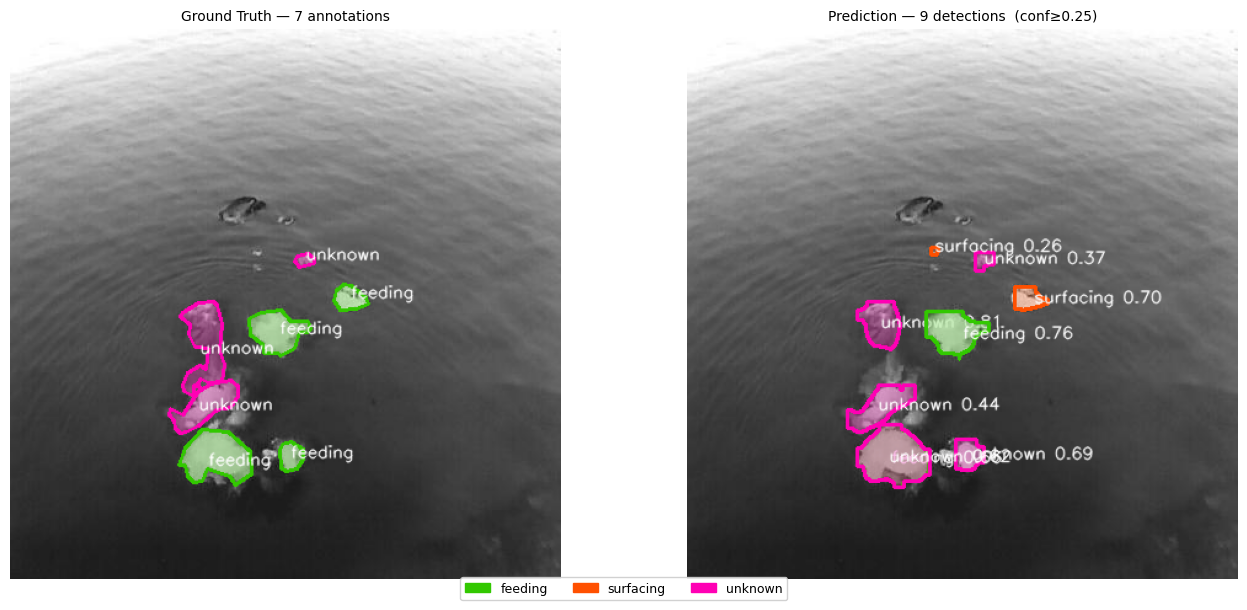

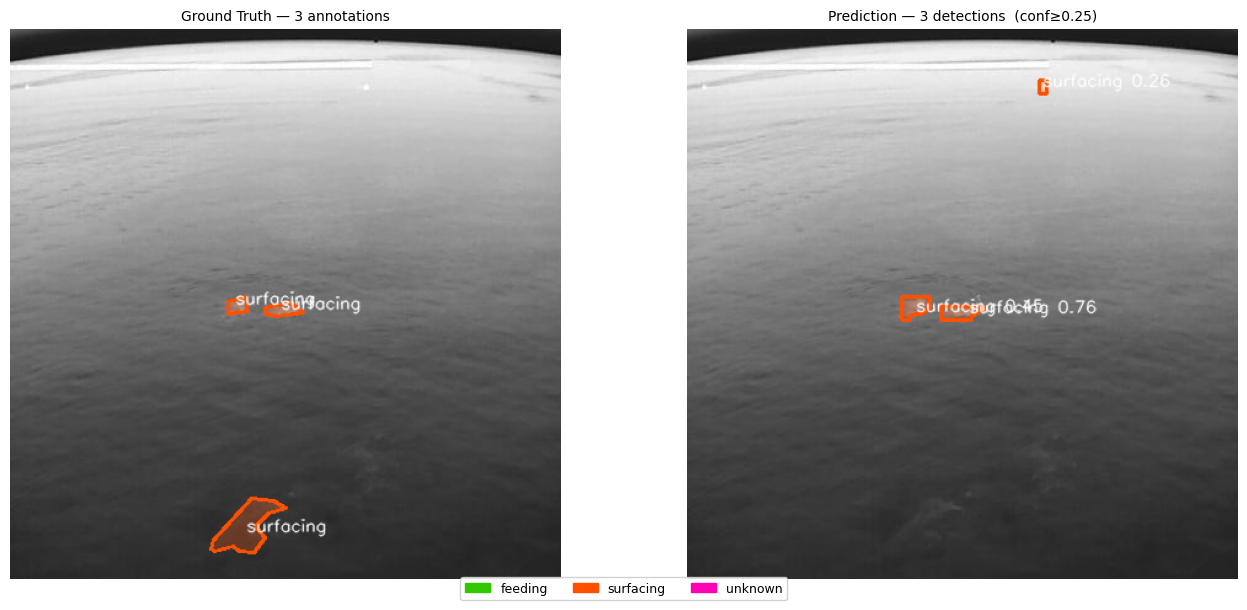

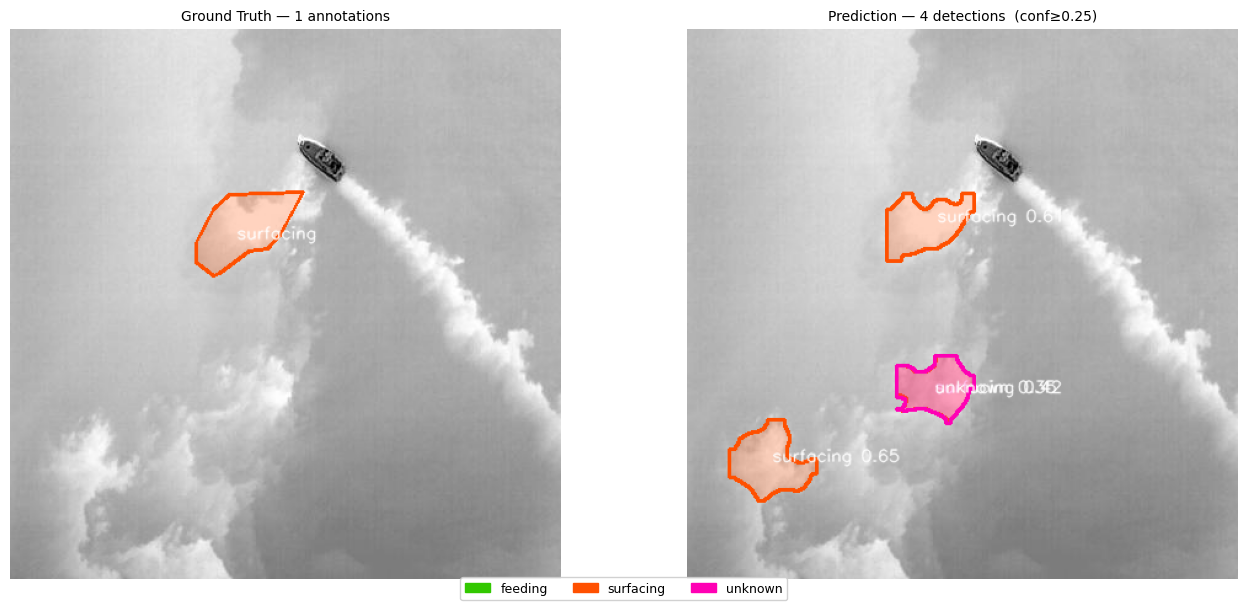

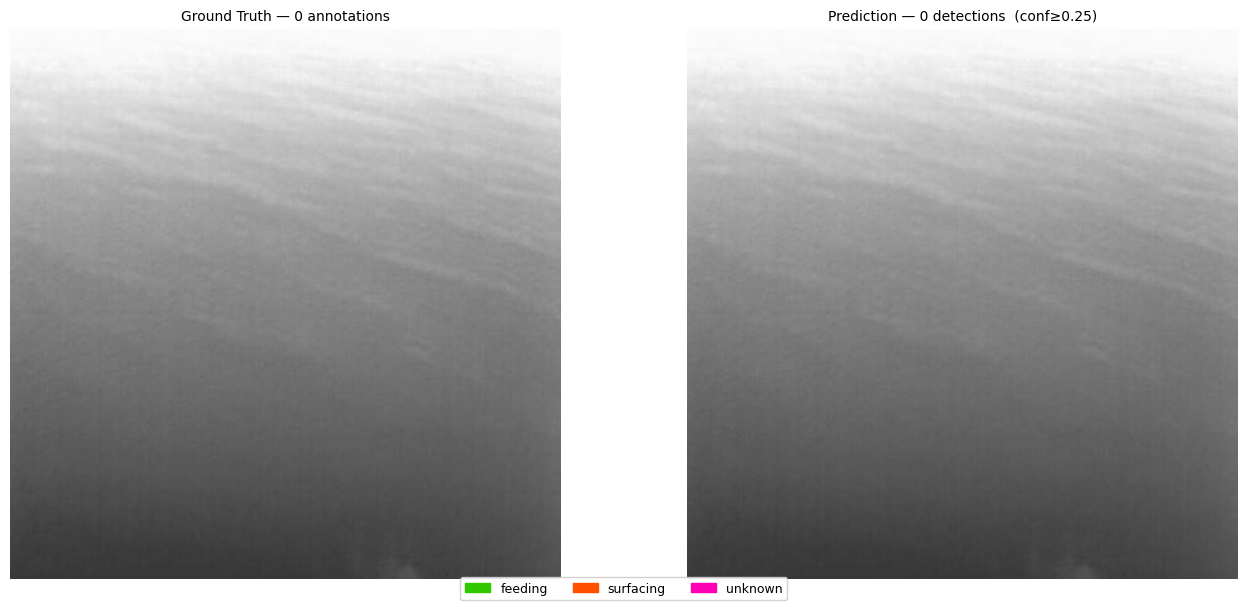

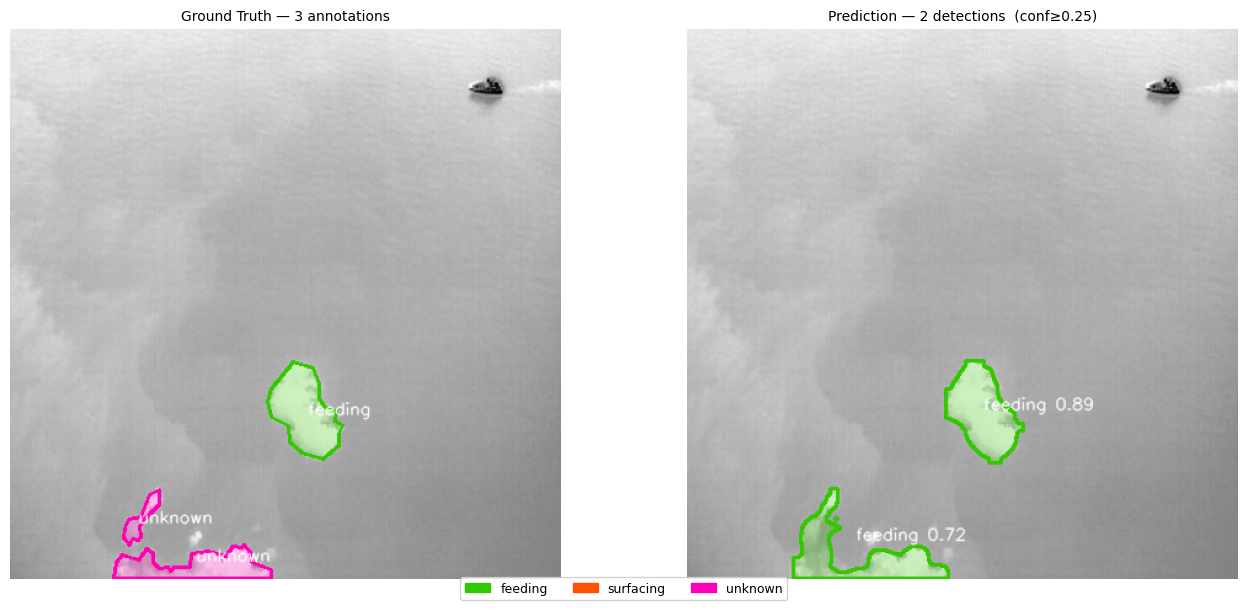

In [7]:
# ── config ────────────────────────────────────────────────────────────────────
PHASE = "M1"   # ← change to "M0", "M1", or "M2"

CONFIGS = {
    "M0": {
        "model_path": Path("runs/segment/train_M0/weights/best.pt"),
        "img_dir":    Path("dataset_M0/test/images"),
        "lbl_dir":    Path("dataset_M0/test/labels"),
        "class_names": {0: "flukeprint"},
        "colors_bgr":  {0: (0, 200, 50)},
    },
    "M1": {
        "model_path": Path("runs/segment/train_M1/weights/best.pt"),
        "img_dir":    Path("dataset_M1/test/images"),
        "lbl_dir":    Path("dataset_M1/test/labels"),
        "class_names": {0: "feeding", 1: "surfacing", 2: "unknown"},
        "colors_bgr":  {0: (0, 200, 50), 1: (0, 80, 255), 2: (180, 0, 255)},
    },
    "M2": {
        "model_path": Path("runs/segment/train_M2/weights/best.pt"),
        "img_dir":    Path("dataset_M2/test/images"),
        "lbl_dir":    Path("dataset_M2/test/labels"),
        "class_names": {
            0: "feeding_fresh", 1: "feeding_old",
            2: "surfacing_fresh", 3: "surfacing_old",
            4: "unknown"
        },
        "colors_bgr": {
            0: (0, 200, 50),      # feeding_fresh   → green
            1: (0, 120, 30),      # feeding_old     → dark green
            2: (0, 80, 255),      # surfacing_fresh → orange
            3: (0, 40, 180),      # surfacing_old   → dark orange
            4: (180, 0, 255),     # unknown         → purple
        },
    },
}

N_IMAGES       = 10
# ─────────────────────────────────────────────────────────────────────────────

cfg         = CONFIGS[PHASE]
model       = YOLO(cfg["model_path"])
class_names = cfg["class_names"]
colors_bgr  = cfg["colors_bgr"]
colors_rgb  = {k: tuple(c/255 for c in reversed(v)) for k, v in colors_bgr.items()}

img_paths = sorted(cfg["img_dir"].glob("*.jpg")) + sorted(cfg["img_dir"].glob("*.png"))
sample    = random.sample(img_paths, min(N_IMAGES, len(img_paths)))


def draw_gt(img_bgr: np.ndarray, lbl_path: Path) -> np.ndarray:
    out = img_bgr.copy()
    h, w = out.shape[:2]
    if not lbl_path.exists():
        return out
    for line in lbl_path.read_text().splitlines():
        parts = line.strip().split()
        if len(parts) < 7:
            continue
        cls_id = int(parts[0])
        coords = list(map(float, parts[1:]))
        pts    = np.array(
            [(coords[i] * w, coords[i+1] * h) for i in range(0, len(coords), 2)],
            dtype=np.int32,
        )
        color = colors_bgr.get(cls_id, (200, 200, 200))
        label = class_names.get(cls_id, str(cls_id))

        overlay = out.copy()
        cv2.fillPoly(overlay, [pts], color=color)
        cv2.addWeighted(overlay, 0.25, out, 0.75, 0, out)
        cv2.polylines(out, [pts], isClosed=True, color=color, thickness=2)

        cx = int(pts[:, 0].mean())
        cy = int(pts[:, 1].mean())
        cv2.putText(out, label, (cx, cy), cv2.FONT_HERSHEY_SIMPLEX,
                    0.45, (255, 255, 255), 1, cv2.LINE_AA)
    return out


def draw_pred(img_bgr: np.ndarray, result) -> np.ndarray:
    out = img_bgr.copy()
    if result.masks is None:
        return out
    for mask_xy, box in zip(result.masks.xy, result.boxes):
        cls_id = int(box.cls)
        conf   = float(box.conf)
        color  = colors_bgr.get(cls_id, (200, 200, 200))
        label  = f"{class_names.get(cls_id, cls_id)} {conf:.2f}"
        pts    = mask_xy.astype(np.int32)

        overlay = out.copy()
        cv2.fillPoly(overlay, [pts], color=color)
        cv2.addWeighted(overlay, 0.25, out, 0.75, 0, out)
        cv2.polylines(out, [pts], isClosed=True, color=color, thickness=2)

        cx = int(pts[:, 0].mean())
        cy = int(pts[:, 1].mean())
        cv2.putText(out, label, (cx, cy), cv2.FONT_HERSHEY_SIMPLEX,
                    0.45, (255, 255, 255), 1, cv2.LINE_AA)
    return out


# ── plot ──────────────────────────────────────────────────────────────────────
for img_path in sample:
    lbl_path = cfg["lbl_dir"] / (img_path.stem + ".txt")
    img_bgr  = cv2.imread(str(img_path))
    result   = model.predict(img_path, conf=CONF_THRESHOLD, iou=IOU_THRESHOLD, verbose=False)[0]

    img_gt   = draw_gt(img_bgr, lbl_path)
    img_pred = draw_pred(img_bgr, result)

    gt_lines = [l for l in lbl_path.read_text().splitlines() if l.strip()] if lbl_path.exists() else []
    n_gt     = len(gt_lines)
    n_pred   = len(result.boxes) if result.boxes is not None else 0

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(cv2.cvtColor(img_gt,   cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Ground Truth — {n_gt} annotations", fontsize=10)
    axes[0].axis("off")

    axes[1].imshow(cv2.cvtColor(img_pred, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"Prediction — {n_pred} detections  (conf≥{CONF_THRESHOLD})", fontsize=10)
    axes[1].axis("off")

    patches = [
        mpatches.Patch(color=colors_rgb[i], label=name)
        for i, name in class_names.items()
    ]
    fig.legend(handles=patches, loc="lower center", ncol=len(class_names),
               fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.02))
    
    plt.tight_layout()
    plt.show()

---
## M1 - Behavioral Distinction - without unknown class

### Label transformation

Original 9 classes → 2 behavioral classes (background is implicit, never labeled)

    0: feeding_fresh          → 0: Feeding
    1: feeding_old            → 0: Feeding
    2: surfacing_fresh        → 1: Surfacing
    3: surfacing_fresh_travel → 1: Surfacing
    4: surfacing_old          → 1: Surfacing
    5: surfacing_old_travel   → 1: Surfacing
    6: traveling_fresh        → DISCARD

    7: traveling_old          → DISCARD
    8: unknown                → DISCARD

Writes to a new dataset folder, never overwrites the original

In [22]:
# ── config ────────────────────────────────────────────────────────────────────
OUTPUT_ROOT  = Path("dataset_M1_no_unknown")

CLASS_MAP = {
    0: 0,   # feeding_fresh          → Feeding
    1: 0,   # feeding_old            → Feeding
    2: 1,   # surfacing_fresh        → Surfacing
    3: 1,   # surfacing_fresh_travel → Surfacing
    4: 1,   # surfacing_old          → Surfacing
    5: 1,   # surfacing_old_travel   → Surfacing
    6: None,   # traveling_fresh        → DISCARD
    7: None,   # traveling_old          → DISCARD
    8: None,   # unknown                → DISCARD
}

CLASS_NAMES = {
    0: "feeding",
    1: "surfacing",
}
# ─────────────────────────────────────────────────────────────────────────────


def transform_label_file(src: Path, dst: Path) -> tuple[Counter, int]:
    lines = src.read_text().splitlines()
    out_lines = []
    counts    = Counter()
    discarded = 0

    for line in lines:
        line = line.strip()
        if not line:
            continue

        parts = line.split()
        original_cls = int(parts[0])

        if original_cls not in CLASS_MAP:
            raise ValueError(
                f"Unexpected class {original_cls} in {src}. "
                f"Expected one of {list(CLASS_MAP.keys())}"
            )

        new_cls = CLASS_MAP[original_cls]

        if new_cls is None:       # ← traveling or unknown → skip, don't write
            discarded += 1
            continue

        parts[0] = str(new_cls)
        counts[new_cls] += 1
        out_lines.append(" ".join(parts))

    dst.parent.mkdir(parents=True, exist_ok=True)
    dst.write_text("\n".join(out_lines))  # may write empty file — that's fine
    return counts, discarded


def main():
    if not DATASET_ROOT.exists():
        raise FileNotFoundError(f"DATASET_ROOT not found: {DATASET_ROOT.resolve()}")

    if OUTPUT_ROOT.exists():
        print(f"[warn] Output folder already exists: {OUTPUT_ROOT.resolve()}")
        print("       Delete it manually if you want a clean run.")

    grand_counts = Counter()

    for split in SPLITS:
        img_src = DATASET_ROOT / split / "images"
        lbl_src = DATASET_ROOT / split / "labels"
        img_dst = OUTPUT_ROOT  / split / "images"
        lbl_dst = OUTPUT_ROOT  / split / "labels"

        # ── images: copy as-is ───────────────────────────────────────────────
        if img_src.exists():
            if img_dst.exists():
                shutil.rmtree(img_dst)
            shutil.copytree(img_src, img_dst)
            n_imgs = len(list(img_dst.iterdir()))
            print(f"[{split}] copied {n_imgs} images")
        else:
            print(f"[{split}] no images folder found, skipping")

        # ── labels: remap classes ────────────────────────────────────────────
        if not lbl_src.exists():
            print(f"[{split}] no labels folder found, skipping")
            continue

        lbl_dst.mkdir(parents=True, exist_ok=True)
        split_counts    = Counter()
        split_discarded = 0

        for lbl_file in sorted(lbl_src.glob("*.txt")):
            counts, discarded = transform_label_file(lbl_file, lbl_dst / lbl_file.name)
            split_counts    += counts
            split_discarded += discarded

        grand_counts += split_counts

        print(f"[{split}] annotation breakdown:")
        for cls_id, name in CLASS_NAMES.items():
            print(f"         class {cls_id} ({name:12s}): {split_counts[cls_id]}")
        print(f"         discarded (traveling)  : {split_discarded}")

    # ── write yaml ───────────────────────────────────────────────────────────
    for yaml_file in DATASET_ROOT.glob("*.yaml"):
        content = yaml_file.read_text()
        content = re.sub(r"nc\s*:\s*\d+", "nc: 2", content)
        content = re.sub(
            r"names\s*:.*?(?=\n\S|\Z)",
            (
                "names:\n"
                "  0: feeding\n"
                "  1: surfacing\n"
            ),
            content,
            flags=re.DOTALL,
        )
        dst_yaml = OUTPUT_ROOT / yaml_file.name
        dst_yaml.parent.mkdir(parents=True, exist_ok=True)
        dst_yaml.write_text(content)
        print(f"\n[yaml] patched and copied → {dst_yaml}")

    print(f"\n✓ Done. Output: {OUTPUT_ROOT.resolve()}")
    print(f"\nGlobal annotation breakdown:")
    total = 0
    for cls_id, name in CLASS_NAMES.items():
        n = grand_counts[cls_id]
        total += n
        print(f"  class {cls_id} ({name:12s}): {n:>6} annotations")
    print(f"  {'TOTAL':>18}: {total:>6} annotations")

In [23]:
if __name__ == "__main__":
    main()

[train] copied 697 images
[train] annotation breakdown:
         class 0 (feeding     ): 600
         class 1 (surfacing   ): 1439
         discarded (traveling)  : 374
[valid] copied 149 images
[valid] annotation breakdown:
         class 0 (feeding     ): 150
         class 1 (surfacing   ): 278
         discarded (traveling)  : 86
[test] copied 149 images
[test] annotation breakdown:
         class 0 (feeding     ): 151
         class 1 (surfacing   ): 295
         discarded (traveling)  : 67

[yaml] patched and copied → dataset_M1_no_unknown/data.yaml

✓ Done. Output: /home/floreM/FlukePrint_YOLO/behav_model/dataset_M1_no_unknown

Global annotation breakdown:
  class 0 (feeding     ):    901 annotations
  class 1 (surfacing   ):   2012 annotations
               TOTAL:   2913 annotations


In [24]:
# ── Training with best hyperparameters ──────────────────────────────────
# Load the best hyperparameters found by the tuner and train.

# ── config ────────────────────────────────────────────────────────────────────
M1_DATASET      = Path("dataset_M1_no_unknown")
M1_YAML         = M1_DATASET / "data.yaml"
M0_BEST         = Path("runs/segment/train_M0/weights/best.pt")  
# ─────────────────────────────────────────────────────────────────────────────

model_m1 = YOLO(M0_BEST)  

with open(MODEL_PARAMS_PATH) as f:
    best_params = yaml.safe_load(f)


model_m1.train(
    data=M1_YAML,
    epochs=150,  
    imgsz=448,
    patience=20,  
    name="train_M1_without",
    **best_params       
)


New https://pypi.org/project/ultralytics/8.4.51 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24215MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.00784, box=5.14291, cache=False, cfg=None, classes=None, close_mosaic=6, cls=0.55957, compile=False, conf=None, copy_paste=0.00314, copy_paste_mode=flip, cos_lr=False, cutmix=0.00571, data=dataset_M1_no_unknown/data.yaml, degrees=0.00017, deterministic=True, device=None, dfl=1.36906, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.48872, flipud=0.0018, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01493, hsv_s=0.64776, hsv_v=0.27383, imgsz=448, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.00218, lrf=0.02127, mask_ratio=4, max_det=300, mixup=0.00285, mode=train, model=run

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ff479ad0310>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.04104

In [25]:
# ── Validation — M1 ───────────────────────────────────────────────

M1_BEST = Path("runs/segment/train_M1_without/weights/best.pt")  

final_model = YOLO(M1_BEST)

metrics = final_model.val(
    data=M1_YAML,
    split="val",
    conf=CONF_THRESHOLD,
    iou=IOU_THRESHOLD,
    verbose=True,
    plots=True
)

p  = metrics.seg.p.mean()
r  = metrics.seg.r.mean()
f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0

print("\n" + "=" * 60)
print("M1 without unknown VALIDATION RESULTS")
print("=" * 60)
print(f"mAP50        (Box):  {metrics.box.map50:.4f}")
print(f"mAP50-95     (Box):  {metrics.box.map:.4f}")
print(f"mAP50        (Mask): {metrics.seg.map50:.4f}")
print(f"mAP50-95     (Mask): {metrics.seg.map:.4f}")
print(f"Recall       (Mask): {r:.4f}")
print(f"Precision    (Mask): {p:.4f}")
print(f"F1           (Mask): {f1:.4f}")
print("=" * 60)


Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24215MiB)
YOLOv8s-seg summary (fused): 86 layers, 11,780,374 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 746.3±243.7 MB/s, size: 10.0 KB)
val: Scanning /home/floreM/FlukePrint_YOLO/behav_model/dataset_M1_no_unknown/valid/labels.cache... 149 images, 21 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 149/149 44.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 5.9it/s 1.7s.1s
                   all        149        428      0.698       0.78      0.784      0.636      0.694      0.776      0.775      0.558
               feeding         69        150       0.71      0.817      0.823        0.7       0.71      0.817      0.823      0.644
             surfacing        104        278      0.685      0.743      0.744      0.573      0.678      0.736  

---
## M2 - Temporal Differentiation

### Label transformation

Original 9 classes → 5 behavioral+temporal classes (background is implicit, never labeled)
 
Mapping:

    0: feeding_fresh          → 0: feeding_fresh    (keep)
    1: feeding_old            → 1: feeding_old       (keep)
    2: surfacing_fresh        → 2: surfacing_fresh
    3: surfacing_fresh_travel → 2: surfacing_fresh   (simplified)
    4: surfacing_old          → 3: surfacing_old
    5: surfacing_old_travel   → 3: surfacing_old     (simplified)
    6: traveling_fresh        → DISCARD
    7: traveling_old          → DISCARD
    8: unknown                → 4: unknown
 
Images with all annotations discarded keep their (empty) label file → negative examples.
Writes to a new dataset folder, never overwrites the original.

In [26]:
# ── config ────────────────────────────────────────────────────────────────────
OUTPUT_ROOT  = Path("dataset_M2")
 
CLASS_MAP = {
    0: 0,     # feeding_fresh          → feeding_fresh
    1: 1,     # feeding_old            → feeding_old
    2: 2,     # surfacing_fresh        → surfacing_fresh
    3: 2,     # surfacing_fresh_travel → surfacing_fresh  (travel context simplified)
    4: 3,     # surfacing_old          → surfacing_old
    5: 3,     # surfacing_old_travel   → surfacing_old    (travel context simplified)
    6: None,  # traveling_fresh        → DISCARD
    7: None,  # traveling_old          → DISCARD
    8: 4,     # unknown                → unknown
}
 
CLASS_NAMES = {
    0: "feeding_fresh",
    1: "feeding_old",
    2: "surfacing_fresh",
    3: "surfacing_old",
    4: "unknown",
}
# ─────────────────────────────────────────────────────────────────────────────
 
 
def transform_label_file(src: Path, dst: Path) -> tuple[Counter, int]:
    """
    Remap class IDs in a YOLOv8 polygon label file.
    Lines whose class maps to None are silently dropped.
    Returns (Counter of {new_class: count}, number of discarded annotations).
    """
    lines     = src.read_text().splitlines()
    out_lines = []
    counts    = Counter()
    discarded = 0
 
    for line in lines:
        line = line.strip()
        if not line:
            continue
 
        parts = line.split()
        original_cls = int(parts[0])
 
        if original_cls not in CLASS_MAP:
            raise ValueError(
                f"Unexpected class {original_cls} in {src}. "
                f"Expected one of {list(CLASS_MAP.keys())}"
            )
 
        new_cls = CLASS_MAP[original_cls]
 
        if new_cls is None:      # traveling → discard
            discarded += 1
            continue
 
        parts[0] = str(new_cls)
        counts[new_cls] += 1
        out_lines.append(" ".join(parts))
 
    dst.parent.mkdir(parents=True, exist_ok=True)
    dst.write_text("\n".join(out_lines))  # empty file = negative example, intentional
    return counts, discarded
 
 
def main():
    if not DATASET_ROOT.exists():
        raise FileNotFoundError(f"DATASET_ROOT not found: {DATASET_ROOT.resolve()}")
 
    if OUTPUT_ROOT.exists():
        print(f"[warn] Output folder already exists: {OUTPUT_ROOT.resolve()}")
        print("       Delete it manually if you want a clean run.")
 
    grand_counts    = Counter()
    grand_discarded = 0
 
    for split in SPLITS:
        img_src = DATASET_ROOT / split / "images"
        lbl_src = DATASET_ROOT / split / "labels"
        img_dst = OUTPUT_ROOT  / split / "images"
        lbl_dst = OUTPUT_ROOT  / split / "labels"
 
        # ── images: copy as-is (empty label = valid negative example) ────────
        if img_src.exists():
            if img_dst.exists():
                shutil.rmtree(img_dst)
            shutil.copytree(img_src, img_dst)
            n_imgs = len(list(img_dst.iterdir()))
            print(f"[{split}] copied {n_imgs} images")
        else:
            print(f"[{split}] no images folder found, skipping")
 
        # ── labels: remap classes ────────────────────────────────────────────
        if not lbl_src.exists():
            print(f"[{split}] no labels folder found, skipping")
            continue
 
        lbl_dst.mkdir(parents=True, exist_ok=True)
        split_counts    = Counter()
        split_discarded = 0
 
        for lbl_file in sorted(lbl_src.glob("*.txt")):
            counts, discarded = transform_label_file(lbl_file, lbl_dst / lbl_file.name)
            split_counts    += counts
            split_discarded += discarded
 
        grand_counts    += split_counts
        grand_discarded += split_discarded
 
        print(f"[{split}] annotation breakdown:")
        for cls_id, name in CLASS_NAMES.items():
            print(f"         class {cls_id} ({name:20s}): {split_counts[cls_id]}")
        print(f"         discarded (traveling)      : {split_discarded}")
 
    # ── write yaml ───────────────────────────────────────────────────────────
    for yaml_file in DATASET_ROOT.glob("*.yaml"):
        content = yaml_file.read_text()
        content = re.sub(r"nc\s*:\s*\d+", "nc: 5", content)
        content = re.sub(
            r"names\s*:.*?(?=\n\S|\Z)",
            (
                "names:\n"
                "  0: feeding_fresh\n"
                "  1: feeding_old\n"
                "  2: surfacing_fresh\n"
                "  3: surfacing_old\n"
                "  4: unknown"
            ),
            content,
            flags=re.DOTALL,
        )
        dst_yaml = OUTPUT_ROOT / yaml_file.name
        dst_yaml.parent.mkdir(parents=True, exist_ok=True)
        dst_yaml.write_text(content)
        print(f"\n[yaml] patched and copied → {dst_yaml}")
 
    print(f"\n{'='*55}")
    print(f"✓ Done. Output: {OUTPUT_ROOT.resolve()}")
    print(f"\nGlobal annotation breakdown:")
    total = 0
    for cls_id, name in CLASS_NAMES.items():
        n = grand_counts[cls_id]
        total += n
        print(f"  class {cls_id} ({name:20s}): {n:>6} annotations")
    print(f"  {'TOTAL':>26}: {total:>6} annotations")
    print(f"  {'discarded (traveling)':>26}: {grand_discarded:>6} annotations")
 

In [27]:
if __name__ == "__main__":
    main()

[train] copied 697 images
[train] annotation breakdown:
         class 0 (feeding_fresh       ): 242
         class 1 (feeding_old         ): 358
         class 2 (surfacing_fresh     ): 608
         class 3 (surfacing_old       ): 831
         class 4 (unknown             ): 144
         discarded (traveling)      : 230
[valid] copied 149 images
[valid] annotation breakdown:
         class 0 (feeding_fresh       ): 70
         class 1 (feeding_old         ): 80
         class 2 (surfacing_fresh     ): 118
         class 3 (surfacing_old       ): 160
         class 4 (unknown             ): 42
         discarded (traveling)      : 44
[test] copied 149 images
[test] annotation breakdown:
         class 0 (feeding_fresh       ): 60
         class 1 (feeding_old         ): 91
         class 2 (surfacing_fresh     ): 146
         class 3 (surfacing_old       ): 149
         class 4 (unknown             ): 20
         discarded (traveling)      : 47

[yaml] patched and copied → dataset_M2/d

In [28]:
# ── Training with best hyperparameters ──────────────────────────────────
# Load the best hyperparameters found by the tuner and train.

# ── config ────────────────────────────────────────────────────────────────────
M2_DATASET      = Path("dataset_M2")
M2_YAML         = M2_DATASET / "data.yaml"
M1_BEST         = Path("runs/segment/train_M1_with/weights/best.pt")  
# ─────────────────────────────────────────────────────────────────────────────

model_m2 = YOLO(M1_BEST)  

with open(MODEL_PARAMS_PATH) as f:
    best_params = yaml.safe_load(f)


model_m2.train(
    data=M2_YAML,
    epochs=150,  
    imgsz=448,
    patience=20,  
    name="train_M2",
    **best_params       
)

New https://pypi.org/project/ultralytics/8.4.51 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24215MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.00784, box=5.14291, cache=False, cfg=None, classes=None, close_mosaic=6, cls=0.55957, compile=False, conf=None, copy_paste=0.00314, copy_paste_mode=flip, cos_lr=False, cutmix=0.00571, data=dataset_M2/data.yaml, degrees=0.00017, deterministic=True, device=None, dfl=1.36906, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.48872, flipud=0.0018, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01493, hsv_s=0.64776, hsv_v=0.27383, imgsz=448, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.00218, lrf=0.02127, mask_ratio=4, max_det=300, mixup=0.00285, mode=train, model=runs/segment/t

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ff64456bf10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,  

In [29]:
# ── Validation — M2 ───────────────────────────────────────────────

M2_BEST = Path("runs/segment/train_M2/weights/best.pt")  

final_model = YOLO(M2_BEST)

metrics = final_model.val(
    data=M2_YAML,
    split="val",
    conf=CONF_THRESHOLD,
    iou=IOU_THRESHOLD,
    verbose=True,
    plots=True
)

p  = metrics.seg.p.mean()
r  = metrics.seg.r.mean()
f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0

print("\n" + "=" * 60)
print("M2 VALIDATION RESULTS")
print("=" * 60)
print(f"mAP50        (Box):  {metrics.box.map50:.4f}")
print(f"mAP50-95     (Box):  {metrics.box.map:.4f}")
print(f"mAP50        (Mask): {metrics.seg.map50:.4f}")
print(f"mAP50-95     (Mask): {metrics.seg.map:.4f}")
print(f"Recall       (Mask): {r:.4f}")
print(f"Precision    (Mask): {p:.4f}")
print(f"F1           (Mask): {f1:.4f}")
print("=" * 60)


Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24215MiB)
YOLOv8s-seg summary (fused): 86 layers, 11,781,535 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 824.5±197.5 MB/s, size: 10.0 KB)
val: Scanning /home/floreM/FlukePrint_YOLO/behav_model/dataset_M2/valid/labels.cache... 149 images, 20 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 149/149 39.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 5.4it/s 1.9s.3s
                   all        149        470      0.568      0.655      0.595      0.474      0.566      0.653      0.592      0.422
         feeding_fresh         48         70      0.723      0.671      0.743      0.613      0.723      0.671      0.743      0.527
           feeding_old         46         80      0.588       0.75      0.716      0.582      0.588       0.75      0.716  

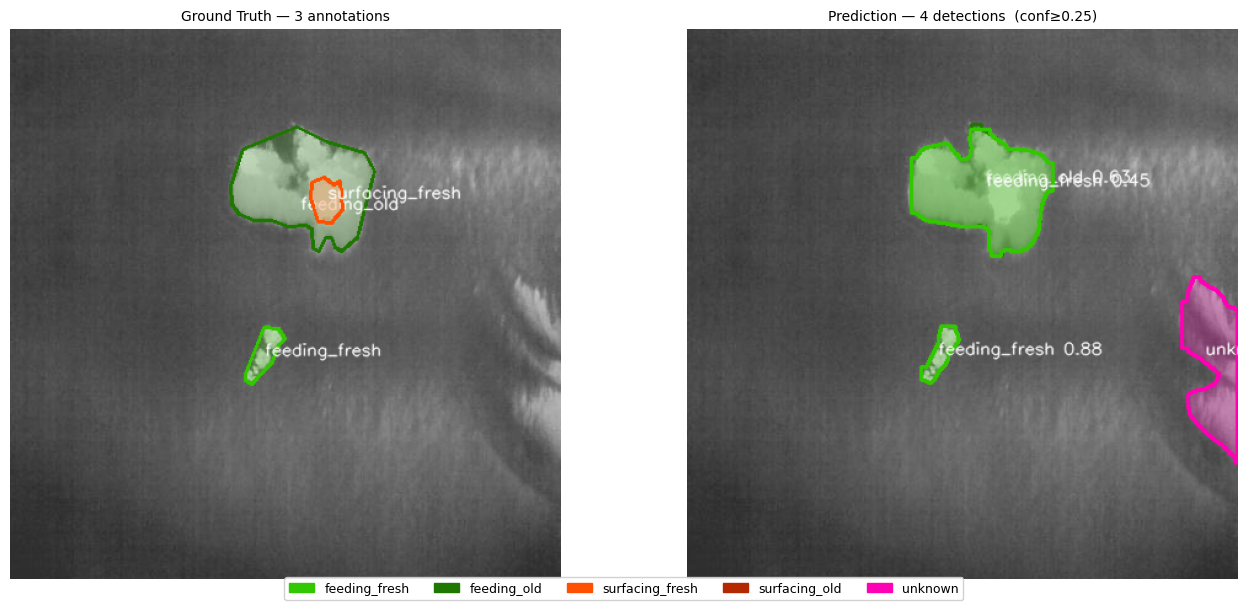

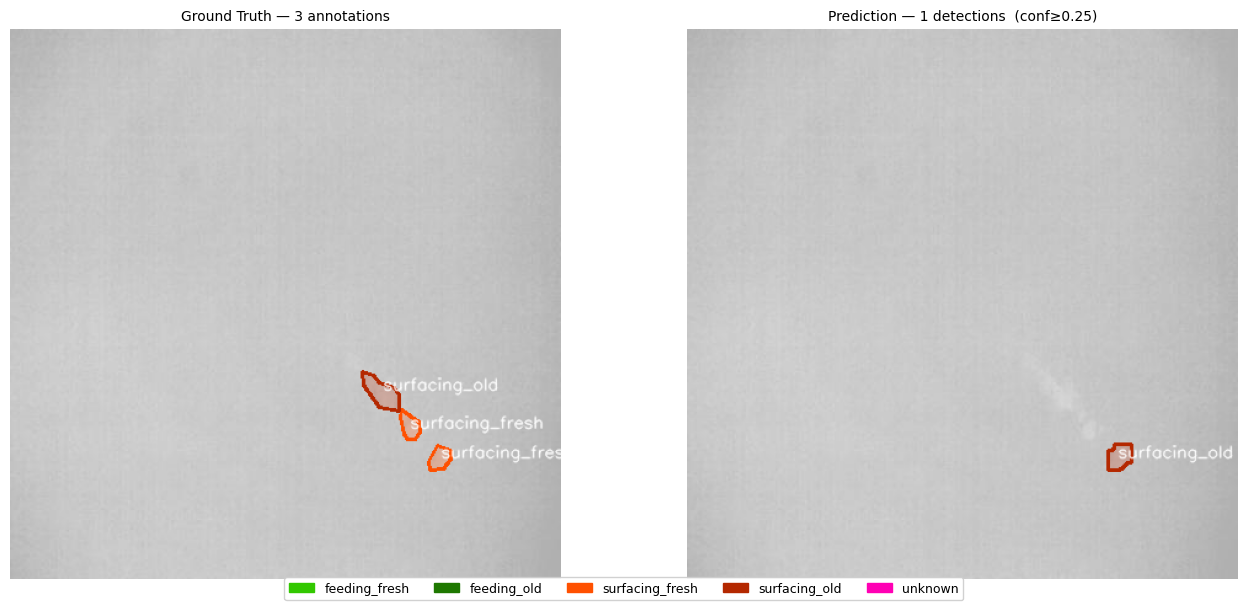

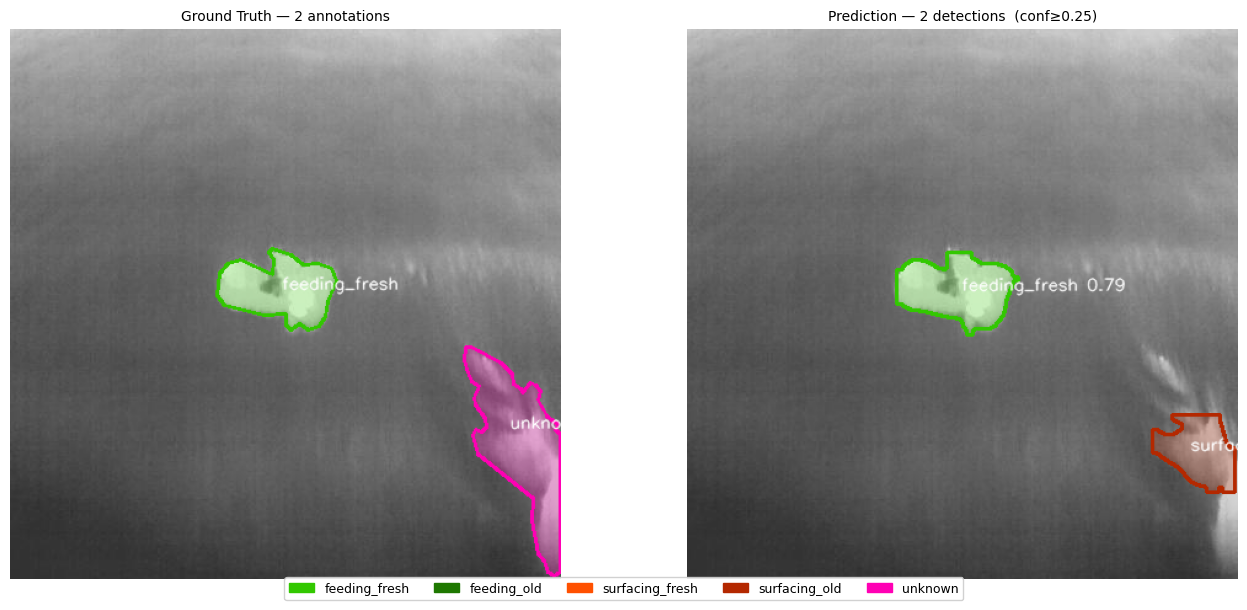

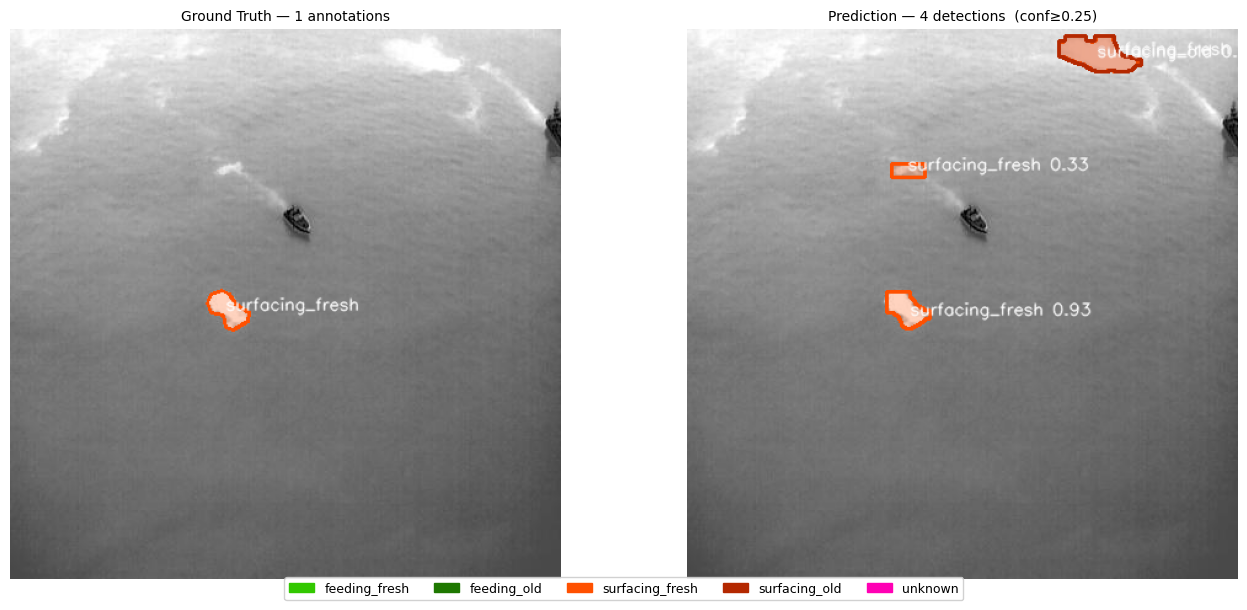

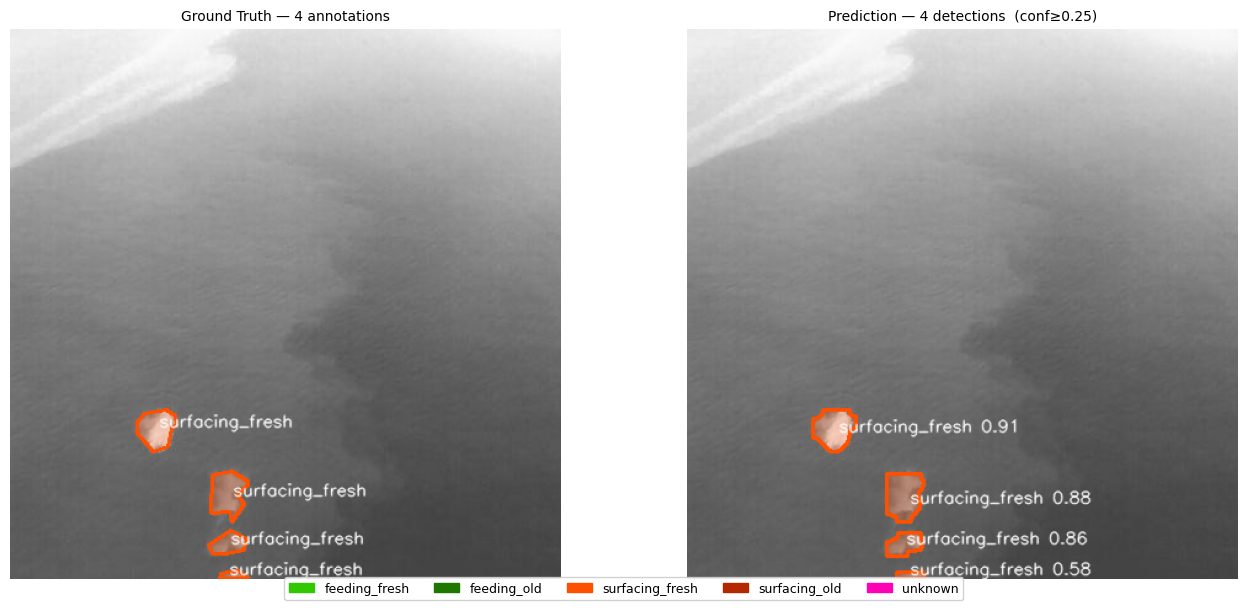

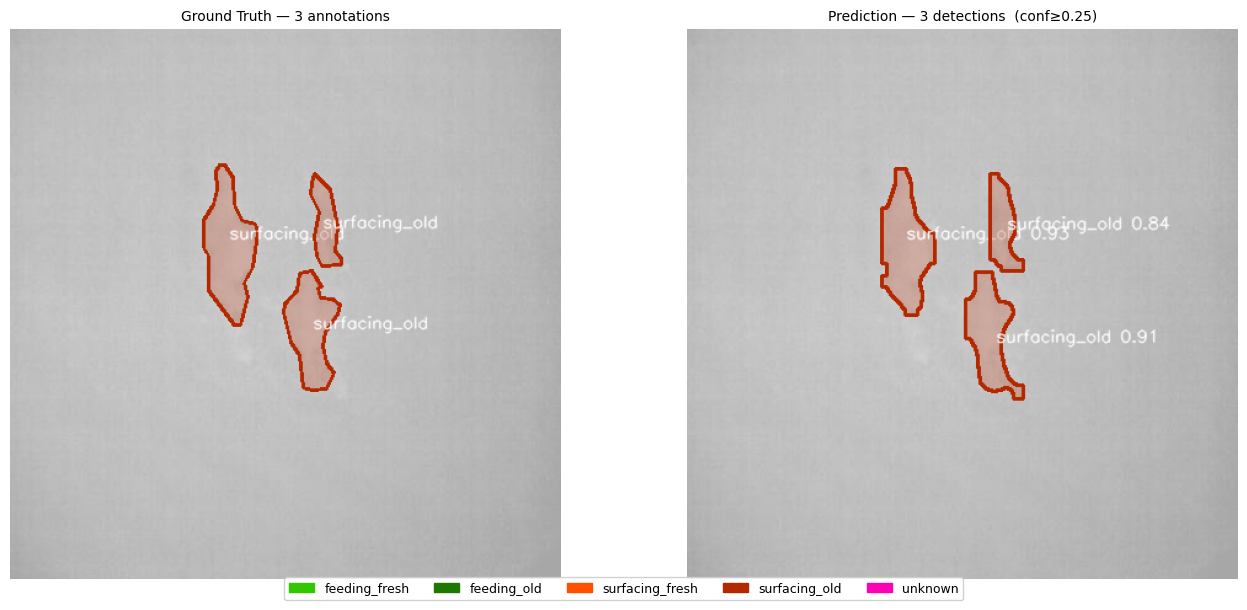

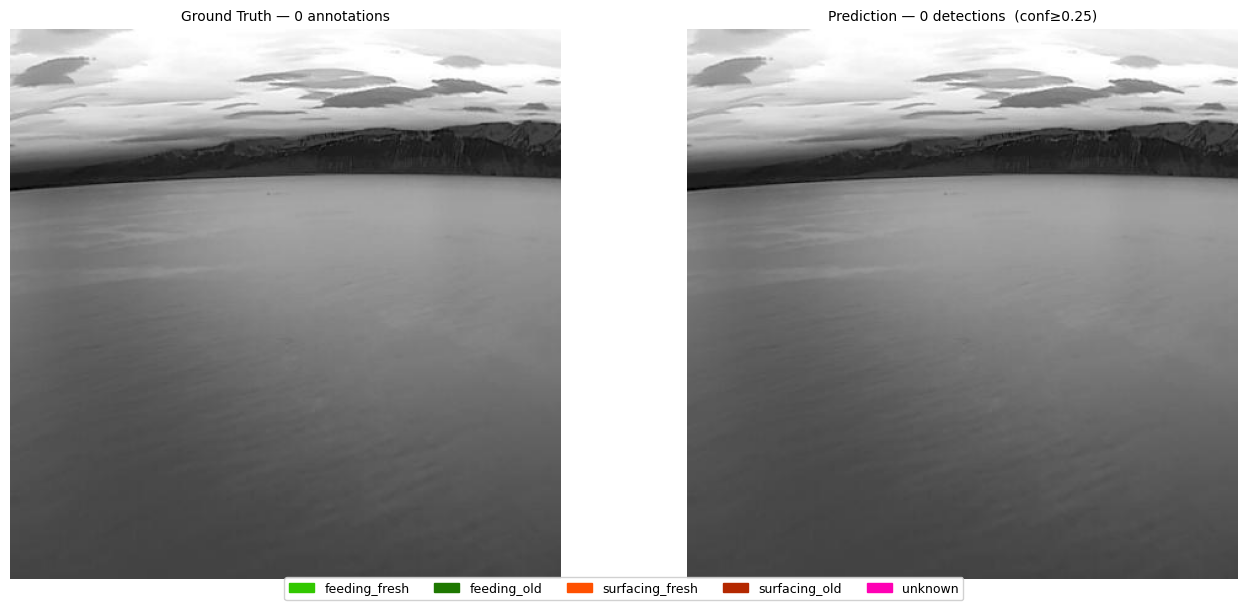

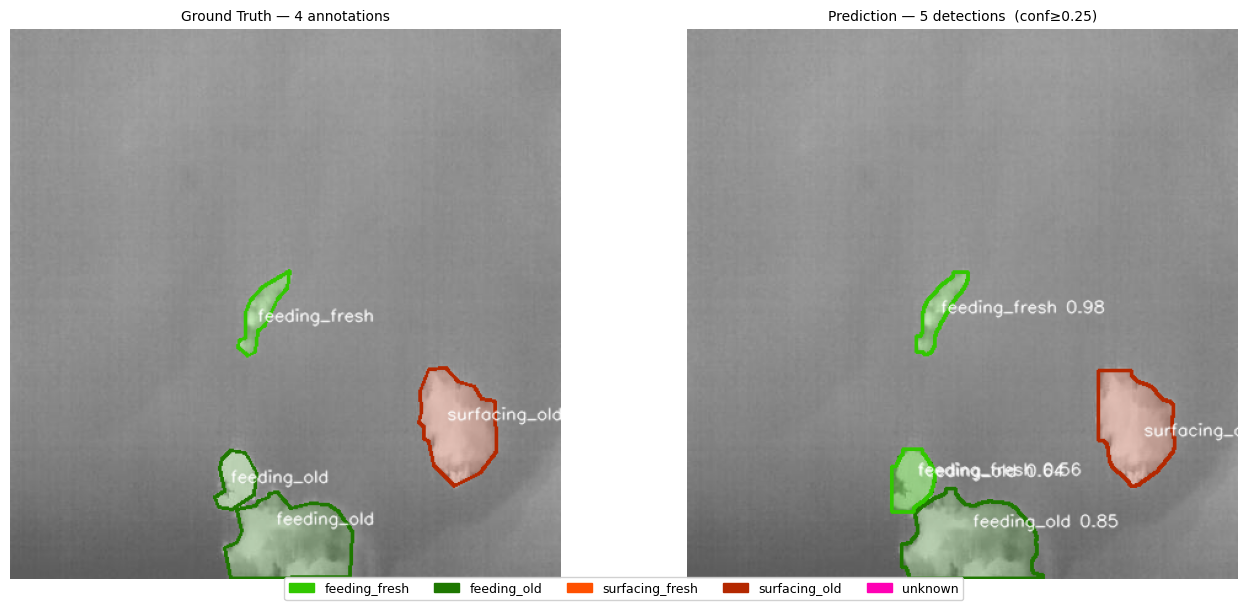

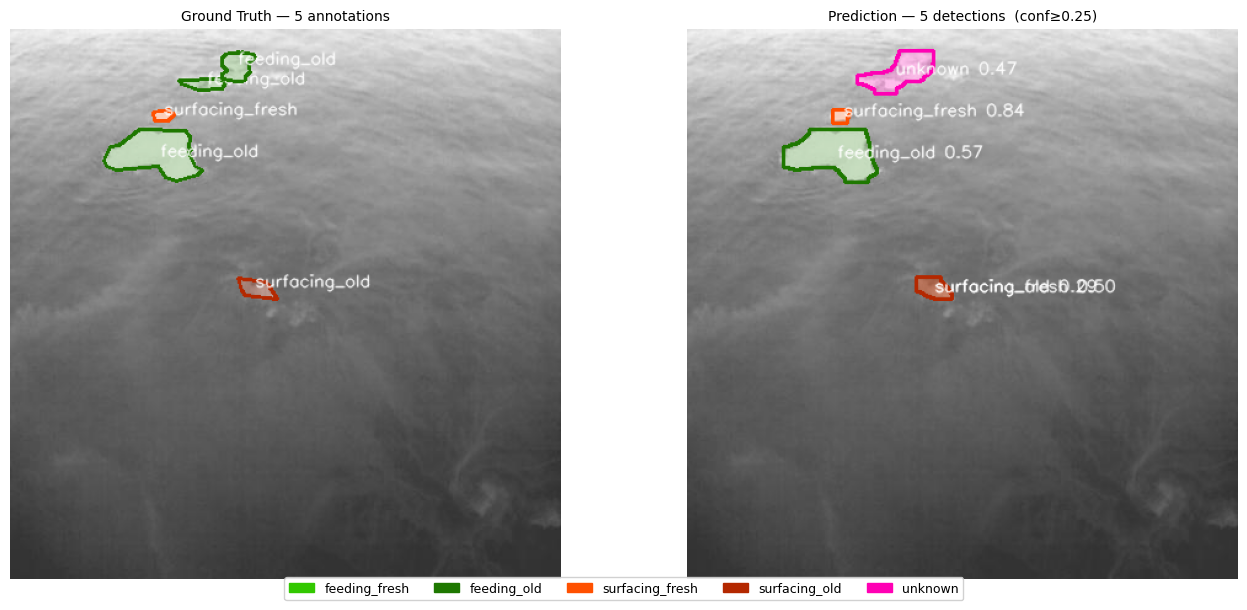

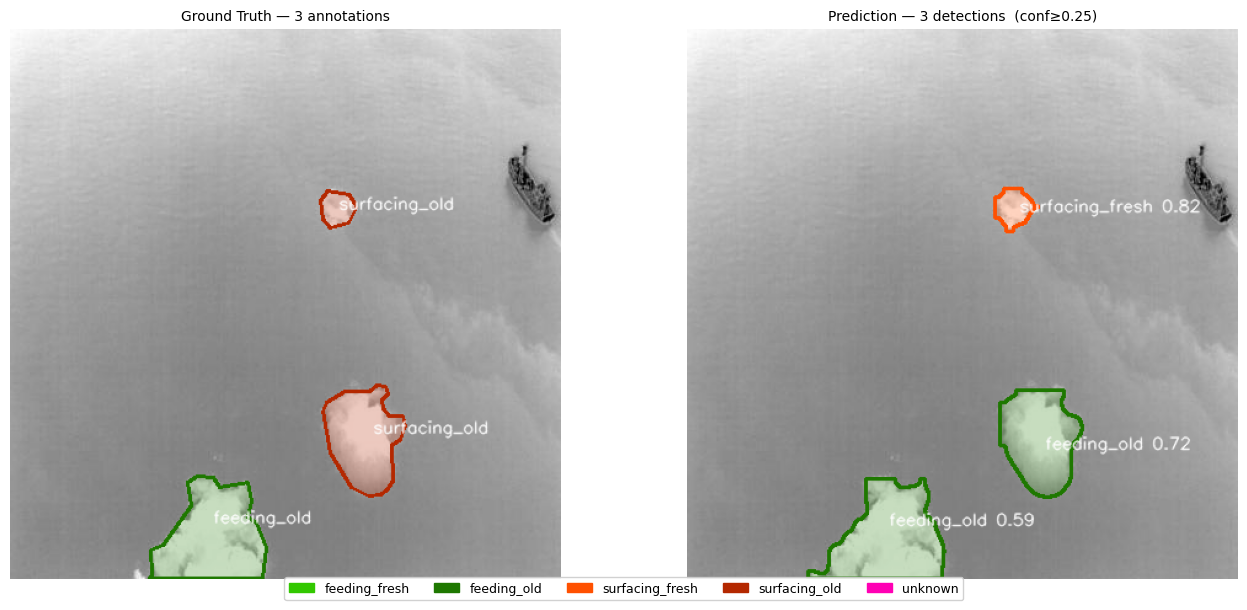

In [8]:
# ── config ────────────────────────────────────────────────────────────────────
PHASE = "M2"   # ← change to "M0", "M1", or "M2"

CONFIGS = {
    "M0": {
        "model_path": Path("runs/segment/train_M0/weights/best.pt"),
        "img_dir":    Path("dataset_M0/test/images"),
        "lbl_dir":    Path("dataset_M0/test/labels"),
        "class_names": {0: "flukeprint"},
        "colors_bgr":  {0: (0, 200, 50)},
    },
    "M1": {
        "model_path": Path("runs/segment/train_M1/weights/best.pt"),
        "img_dir":    Path("dataset_M1/test/images"),
        "lbl_dir":    Path("dataset_M1/test/labels"),
        "class_names": {0: "feeding", 1: "surfacing", 2: "unknown"},
        "colors_bgr":  {0: (0, 200, 50), 1: (0, 80, 255), 2: (180, 0, 255)},
    },
    "M2": {
        "model_path": Path("runs/segment/train_M2/weights/best.pt"),
        "img_dir":    Path("dataset_M2/test/images"),
        "lbl_dir":    Path("dataset_M2/test/labels"),
        "class_names": {
            0: "feeding_fresh", 1: "feeding_old",
            2: "surfacing_fresh", 3: "surfacing_old",
            4: "unknown"
        },
        "colors_bgr": {
            0: (0, 200, 50),      # feeding_fresh   → green
            1: (0, 120, 30),      # feeding_old     → dark green
            2: (0, 80, 255),      # surfacing_fresh → orange
            3: (0, 40, 180),      # surfacing_old   → dark orange
            4: (180, 0, 255),     # unknown         → purple
        },
    },
}

N_IMAGES       = 10
# ─────────────────────────────────────────────────────────────────────────────

cfg         = CONFIGS[PHASE]
model       = YOLO(cfg["model_path"])
class_names = cfg["class_names"]
colors_bgr  = cfg["colors_bgr"]
colors_rgb  = {k: tuple(c/255 for c in reversed(v)) for k, v in colors_bgr.items()}

img_paths = sorted(cfg["img_dir"].glob("*.jpg")) + sorted(cfg["img_dir"].glob("*.png"))
sample    = random.sample(img_paths, min(N_IMAGES, len(img_paths)))


def draw_gt(img_bgr: np.ndarray, lbl_path: Path) -> np.ndarray:
    out = img_bgr.copy()
    h, w = out.shape[:2]
    if not lbl_path.exists():
        return out
    for line in lbl_path.read_text().splitlines():
        parts = line.strip().split()
        if len(parts) < 7:
            continue
        cls_id = int(parts[0])
        coords = list(map(float, parts[1:]))
        pts    = np.array(
            [(coords[i] * w, coords[i+1] * h) for i in range(0, len(coords), 2)],
            dtype=np.int32,
        )
        color = colors_bgr.get(cls_id, (200, 200, 200))
        label = class_names.get(cls_id, str(cls_id))

        overlay = out.copy()
        cv2.fillPoly(overlay, [pts], color=color)
        cv2.addWeighted(overlay, 0.25, out, 0.75, 0, out)
        cv2.polylines(out, [pts], isClosed=True, color=color, thickness=2)

        cx = int(pts[:, 0].mean())
        cy = int(pts[:, 1].mean())
        cv2.putText(out, label, (cx, cy), cv2.FONT_HERSHEY_SIMPLEX,
                    0.45, (255, 255, 255), 1, cv2.LINE_AA)
    return out


def draw_pred(img_bgr: np.ndarray, result) -> np.ndarray:
    out = img_bgr.copy()
    if result.masks is None:
        return out
    for mask_xy, box in zip(result.masks.xy, result.boxes):
        cls_id = int(box.cls)
        conf   = float(box.conf)
        color  = colors_bgr.get(cls_id, (200, 200, 200))
        label  = f"{class_names.get(cls_id, cls_id)} {conf:.2f}"
        pts    = mask_xy.astype(np.int32)

        overlay = out.copy()
        cv2.fillPoly(overlay, [pts], color=color)
        cv2.addWeighted(overlay, 0.25, out, 0.75, 0, out)
        cv2.polylines(out, [pts], isClosed=True, color=color, thickness=2)

        cx = int(pts[:, 0].mean())
        cy = int(pts[:, 1].mean())
        cv2.putText(out, label, (cx, cy), cv2.FONT_HERSHEY_SIMPLEX,
                    0.45, (255, 255, 255), 1, cv2.LINE_AA)
    return out


# ── plot ──────────────────────────────────────────────────────────────────────
for img_path in sample:
    lbl_path = cfg["lbl_dir"] / (img_path.stem + ".txt")
    img_bgr  = cv2.imread(str(img_path))
    result   = model.predict(img_path, conf=CONF_THRESHOLD, iou=IOU_THRESHOLD, verbose=False)[0]

    img_gt   = draw_gt(img_bgr, lbl_path)
    img_pred = draw_pred(img_bgr, result)

    gt_lines = [l for l in lbl_path.read_text().splitlines() if l.strip()] if lbl_path.exists() else []
    n_gt     = len(gt_lines)
    n_pred   = len(result.boxes) if result.boxes is not None else 0

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(cv2.cvtColor(img_gt,   cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Ground Truth — {n_gt} annotations", fontsize=10)
    axes[0].axis("off")

    axes[1].imshow(cv2.cvtColor(img_pred, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"Prediction — {n_pred} detections  (conf≥{CONF_THRESHOLD})", fontsize=10)
    axes[1].axis("off")

    patches = [
        mpatches.Patch(color=colors_rgb[i], label=name)
        for i, name in class_names.items()
    ]
    fig.legend(handles=patches, loc="lower center", ncol=len(class_names),
               fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.02))
    
    plt.tight_layout()
    plt.show()